# E67 · Ranking from head-to-head results: Bradley-Terry, dynamic skill ratings and Plackett-Luce

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real, two sources, both CC BY-NC-SA 4.0 (non-commercial, share-alike). **ATP tennis**: every men's tour-level singles match from January 2021 to Roland Garros 2026 (Jeff Sackmann's `tennis_atp`, via an archival mirror), restricted to the 60 busiest players. **Formula 1**: every Grand Prix and sprint classification 2021-2025 (Jolpica-F1, the successor of the Ergast API). Simulated data with known truth are used once, to check the Plackett-Luce model, and are labelled as such |
| **You will learn** | The **Bradley-Terry** model (win probability = logistic of a skill difference) · why skills are only identified up to a constant: an **improper flat prior** that samples "fine" with r_hat 1.8, a **sum-to-zero** fix with `pm.ZeroSumNormal`, and what **anchoring** one player does to everybody's uncertainty · **hierarchical skill priors** and **surface-specific effects** (clay, grass, hard) as partial pooling · **dynamic skill**: a Gaussian random walk per player (a Bayesian Elo / Glicko / TrueSkill-through-time) next to **plain Elo** on the same scale · a **posterior predictive check that cannot fail** (a sufficient statistic) and one that can · **held-out prediction** a year ahead: log score and Brier score against Elo, ATP ranking points and a coin, with paired standard errors, and a calibration plot · **ranking uncertainty**: P(each player is the best), posterior rank distributions, a simulated grass-court knockout · the **Plackett-Luce** model for whole finishing orders written as a sequential softmax in PyTensor, checked by brute force and by the Gumbel-max trick, recovered from **simulated known truth** · separating **driver from car** in Formula 1 with teammates, in-season car development as a random walk · a teammate-duel check that exposes **correlated race-day noise**, fixed by a shared team effect · a **2025 title forecast** from round 15 that the season then refuted |

## The question

Rankings are built from results between a few competitors at a time: two players in a tennis
match, twenty cars in a Grand Prix. Nobody plays everybody, the schedule is not random (good
players meet good players in late rounds), form changes over time, and in motor racing the
machine matters as much as the driver. Official rankings (ATP ranking points, championship
points) are *accounting* rules: they reward results, not skill, and give no uncertainty.

A **paired-comparison model** turns results into skills with honest uncertainty. The oldest one,
**Bradley-Terry** (Zermelo 1929; Bradley & Terry 1952), says player $i$ beats player $j$ with
probability

$$P(i \text{ beats } j) = \operatorname{logit}^{-1}(\theta_i - \theta_j).$$

**Elo** ratings (Elo 1978), used in chess and by many sports sites, are an online, point-estimate
version of the same model with a fixed learning rate. **Plackett-Luce** (Luce 1959; Plackett 1975)
extends it from pairs to whole finishing orders. We fit all three and use them to answer questions
people actually ask: *who is the best player right now, and how sure are we? Who wins a
tournament? Who is the best Formula 1 driver once the car is taken out, and who will be champion?*

## The plan

| part | question | tool |
|---|---|---|
| A1-A2 | How good is each tennis player? Why does the naive model not converge? | Bradley-Terry, sum-to-zero vs anchoring |
| A3-A4 | Do players differ by surface? Does the model reproduce the data? | partial pooling, posterior predictive checks |
| A5-A6 | How does skill change over time? Does it predict next year better than Elo? | Gaussian random-walk skills, held-out log score |
| A7 | Who is the best player now? Who wins a knockout? | P(best), rank posteriors, tournament simulation |
| B1-B2 | How do we score a whole finishing order? Does the model recover a known truth? | Plackett-Luce as a sequential softmax, simulation check |
| B3-B5 | Driver or car? Who wins the 2025 title? | teammates, a race-day team effect, in-season car development, a forecast checked against what happened |

In [1]:
import itertools
import logging
import time
import warnings

import arviz as az
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
from IPython.display import display
from scipy import optimize, special

from pymc_challenges import data

RANDOM_SEED = 67
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
SURF_COL = {"Hard": BLUE, "Clay": ORANGE, "Grass": AQUA}
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def fit(model, label, **kwargs):
    """Sample with nutpie, report time, divergences and warm-up length."""
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False, **kwargs)
    n_div = int(idata.sample_stats["diverging"].sum())
    print(f"{label}: {time.time() - t0:.0f} s, {n_div} divergences, "
          f"{idata.posterior.attrs['tuning_steps']} warm-up steps per chain")
    return idata


def worst(idata, names):
    """Largest r_hat and smallest bulk ESS over the named variables."""
    rh = max(float(az.rhat(idata.posterior[v]).max()) for v in names)
    es = min(float(az.ess(idata.posterior[v]).min()) for v in names)
    return f"max r_hat {rh:.3f}, min bulk ESS {es:.0f}"


def draws(idata, name):
    """Posterior draws with chain and draw stacked into the first axis."""
    x = idata.posterior[name].values
    return x.reshape((-1,) + x.shape[2:])

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


# Part A · Tennis: who beats whom

## The data

In [2]:
data.describe("atp_tour_matches")
atp = data.load("atp_tour_matches")
atp["date"] = pd.to_datetime(atp["tourney_date"].astype(str), format="%Y%m%d")
n_all = len(atp)
unfinished = atp["score"].str.contains("W/O|RET|DEF", na=True)
atp = atp[~unfinished].reset_index(drop=True)
print(f"{n_all:,} tour-level matches; dropped {unfinished.sum()} walkovers, retirements and defaults")

SPLIT = pd.Timestamp("2025-07-01")               # fit before, predict after
train_all = atp[atp.date < SPLIT]
n_matches = pd.concat([train_all.winner_name, train_all.loser_name]).value_counts()
players = np.array(sorted(n_matches.index[:60]))  # the 60 busiest players before the split
pidx = pd.Index(players)
NP = len(players)
tm = atp[atp.winner_name.isin(players) & atp.loser_name.isin(players)].copy()
w, lo = pidx.get_indexer(tm.winner_name), pidx.get_indexer(tm.loser_name)
tm["a"], tm["b"] = np.minimum(w, lo), np.maximum(w, lo)   # alphabetical: a is not "the winner"
tm["y"] = (w < lo).astype(int)                             # 1 if player a won
SURFACES = ["Hard", "Clay", "Grass"]
tm["s"] = pd.Index(SURFACES).get_indexer(tm.surface)
tm["quarter"] = (tm.date.dt.year - 2021) * 4 + (tm.date.dt.month - 1) // 3
tr, te = tm[tm.date < SPLIT].copy(), tm[tm.date >= SPLIT].copy()
print(f"{NP} players; {len(tm):,} matches between them: {len(tr):,} to fit (Jan 2021 - Jun 2025), "
      f"{len(te):,} held out (Jul 2025 to Roland Garros 2026)")
print(f"fewest matches in the fitting period: {n_matches.iloc[59]} (per player, against anyone)")
print("surfaces (fitting period):", tr.surface.value_counts().to_dict())
fav = tr[["winner_rank", "loser_rank"]].dropna()
print(f"higher-ranked player won {np.mean(fav.winner_rank < fav.loser_rank):.1%} of the matches")

atp_tour_matches: ATP men's tour-level singles matches, 2021-01 to 2026-06-07 (Roland Garros 2026 is the last event): 14,844 matches, one row per match, winner first. Levels G (Grand Slam), M (Masters 1000), A (ATP 250/500 and other tour events), F (season finals); Davis Cup, Challengers and qualifying excluded. Columns: tourney_id, tourney_name, surface (Hard/Clay/Grass), tourney_level, tourney_date (YYYYMMDD, usually the Monday of the event week), round (R128...F, RR), best_of (3 or 5), match_num, winner_id, winner_name, loser_id, loser_name, winner_rank / loser_rank and *_rank_points (ATP ranking at the time), score (contains RET, W/O or DEF for retirements, walkovers, defaults).
  source: Jeff Sackmann, tennis_atp (github.com/JeffSackmann/tennis_atp), CC BY-NC-SA 4.0 (non-commercial, share-alike). The upstream repository was unreachable (404) on 2026-09-28; downloaded from the archival mirror github.com/Aneeshers/tennis-sackmann-archive (atp/atp_matches_2021.csv ... atp_matches_202

Two data decisions matter. **Unfinished matches** (walkovers, retirements, defaults) are dropped:
an injury retirement says little about who is the better player. **The player set** is the 60
players with the most tour-level matches before July 2025, and only matches between two of them
are kept. Every one of them played at least 141 tour-level matches in the fitting period, so we
can study the model rather than fight sparsity. The price is that players who rose recently (and
players who beat our 60 from outside) are invisible; a real rating system would include
everyone and let the hierarchical prior handle the sparse ones.

Each match is recorded with player $a$ the alphabetically first, and $y=1$ if $a$ won - the raw
files list the winner first, and a model fitted to "the first-named player always wins" learns
nothing.

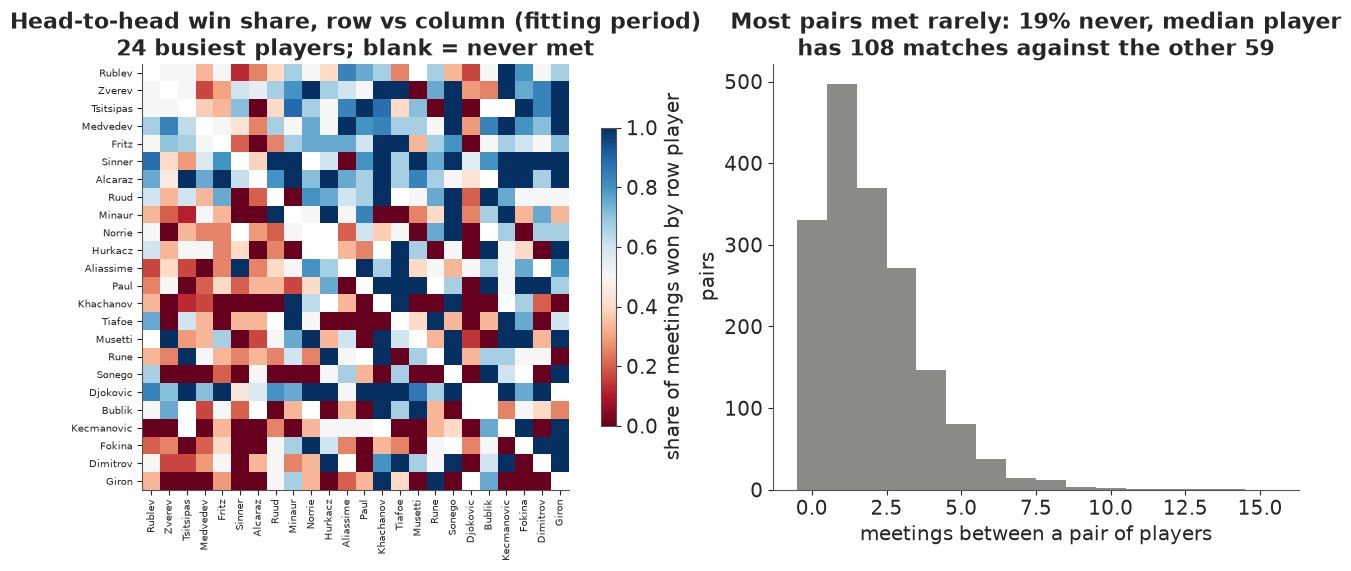

In [3]:
top_order = n_matches.loc[players].sort_values(ascending=False).index[:24]
k24 = pidx.get_indexer(top_order)
wins_m = np.zeros((NP, NP))
np.add.at(wins_m, (np.where(tr.y == 1, tr.a, tr.b), np.where(tr.y == 1, tr.b, tr.a)), 1)
games = wins_m + wins_m.T
share = np.where(games > 0, wins_m / np.maximum(games, 1), np.nan)[np.ix_(k24, k24)]
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6), width_ratios=[1.25, 1])
im = axes[0].imshow(share, cmap="RdBu", vmin=0, vmax=1)
short = [p.split()[-1] for p in top_order]
axes[0].set_xticks(range(24), short, rotation=90, fontsize=7)
axes[0].set_yticks(range(24), short, fontsize=7)
axes[0].set(title="Head-to-head win share, row vs column (fitting period)\n"
            "24 busiest players; blank = never met")
fig.colorbar(im, ax=axes[0], shrink=0.7, label="share of meetings won by row player")
axes[0].grid(False)
nm = games.sum(axis=1)
axes[1].hist(games[np.triu_indices(NP, 1)], bins=np.arange(-0.5, 16.5), color=GREY)
axes[1].set(xlabel="meetings between a pair of players", ylabel="pairs",
            title=f"Most pairs met rarely: {np.mean(games[np.triu_indices(NP, 1)] == 0):.0%} "
            "never, median player\nhas "
            f"{np.median(nm):.0f} matches against the other 59");

The head-to-head table is thin: a fifth of all pairs never met, and most of the rest met one to
three times - a ranking read off it directly would be noise. Bradley-Terry connects everybody
through common opponents: if A beats B and B beats C, the model learns something about A vs C
without them ever meeting.

## A1 · Bradley-Terry and its prior

The model has one skill per player, $\theta_i$, on the log-odds scale. With a hierarchical prior
$\theta_i \sim \mathcal N(0, \sigma_\theta)$, the spread $\sigma_\theta$ says how different tour
players are. What does a prior $\sigma_\theta \sim \text{HalfNormal}(1)$ imply? Before fitting,
we simulate two numbers a tennis fan has an opinion about: the chance that a random player
beats another random player (should be spread around 50%, rarely 95%), and the chance that
the best of 60 beats a middle-ranked player.

prior: P(best beats middle) median 0.82, 90% interval [0.54 0.99]


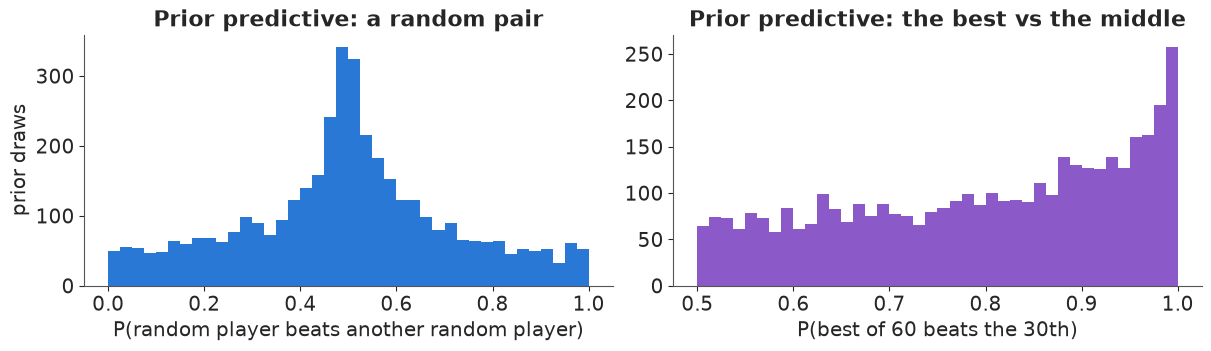

In [4]:
sig_prior = np.abs(rng.normal(0, 1, 4000))
th_prior = rng.normal(0, 1, (4000, NP)) * sig_prior[:, None]
p_random = special.expit(th_prior[:, 0] - th_prior[:, 1])
srt = np.sort(th_prior, axis=1)
p_best_mid = special.expit(srt[:, -1] - srt[:, NP // 2])
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(p_random, bins=40, color=BLUE)
axes[0].set(xlabel="P(random player beats another random player)", ylabel="prior draws",
            title="Prior predictive: a random pair")
axes[1].hist(p_best_mid, bins=40, color=PURPLE)
axes[1].set(xlabel="P(best of 60 beats the 30th)", title="Prior predictive: the best vs the middle")
print(f"prior: P(best beats middle) median {np.median(p_best_mid):.2f}, "
      f"90% interval {np.quantile(p_best_mid, [0.05, 0.95]).round(2)}");

The prior puts a random pair near a coin flip most often (with some lopsided pairs), and gives
the best of 60 a median 82% chance against the 30th (90% interval 54-99%): anything from
"nearly all equal" to "the best
player almost never loses to a middle one". That covers every plausible tennis tour without
spending prior mass on absurd skill gaps of 10 logits.

## A2 · The first failure: skills without a zero

Only *differences* $\theta_i - \theta_j$ enter the likelihood. Add 5 to every skill and every
win probability is unchanged. A model with a flat, improper prior on each $\theta_i$ therefore has
a posterior that is flat along the direction "everybody up by the same amount". NUTS still runs,
reports no divergences, and every chain wanders to its own level.

In [5]:
coords = {"player": players, "surface": SURFACES}
ya_tr, yb_tr, s_tr = tr.a.to_numpy(), tr.b.to_numpy(), tr.s.to_numpy()
with pm.Model(coords=coords) as m_flat:
    theta = pm.Flat("theta", dims="player")
    pm.Bernoulli("y", logit_p=theta[ya_tr] - theta[yb_tr], observed=tr.y.to_numpy())
id_flat = fit(m_flat, "flat prior")
ks, kr = pidx.get_loc("Jannik Sinner"), pidx.get_loc("Casper Ruud")
th_f = id_flat.posterior["theta"]
diff_f = th_f.isel(player=ks) - th_f.isel(player=kr)
print(f"skills: {worst(id_flat, ['theta'])}")
print(f"Sinner's skill, chain means: {th_f.isel(player=ks).mean('draw').values.round(2)}")
print(f"Sinner - Ruud:  r_hat {float(az.rhat(diff_f)):.3f}, chain means "
      f"{diff_f.mean('draw').values.round(2)}")

flat prior: 4 s, 0 divergences, 400 warm-up steps per chain
skills: max r_hat 1.922, min bulk ESS 6
Sinner's skill, chain means: [ 1.75  0.23  1.33 -0.56]
Sinner - Ruud:  r_hat 1.001, chain means [0.94 0.94 0.94 0.94]


Two standard fixes pin the level down:

* **Sum to zero**: $\sum_i \theta_i = 0$, so a skill means "better or worse than the average of
  these 60 players". `pm.ZeroSumNormal` puts a normal prior on the constrained space directly;
  here it doubles as the hierarchical prior with a learned spread $\sigma_\theta$.
* **Anchor** one player at 0 (the "reference category" of a regression). Also identified - but
  every other skill is now measured relative to one person, and that person's uncertainty is
  pushed onto everyone else.

In [6]:
with pm.Model(coords=coords) as m_bt:
    sigma_theta = pm.HalfNormal("sigma_theta", 1.0)
    theta = pm.ZeroSumNormal("theta", sigma=sigma_theta, dims="player")
    pm.Bernoulli("y", logit_p=theta[ya_tr] - theta[yb_tr], observed=tr.y.to_numpy())
id_bt = fit(m_bt, "sum-to-zero, hierarchical")
print(f"skills: {worst(id_bt, ['theta'])}")

ANCHOR = "Adrian Mannarino"
k_anchor = pidx.get_loc(ANCHOR)
with pm.Model(coords=coords) as m_anchor:
    free = pm.Flat("theta_free", shape=NP - 1)
    theta = pm.Deterministic("theta", pt.concatenate([free[:k_anchor], pt.zeros(1), free[k_anchor:]]),
                             dims="player")
    pm.Bernoulli("y", logit_p=theta[ya_tr] - theta[yb_tr], observed=tr.y.to_numpy())
id_anchor = fit(m_anchor, f"anchored at {ANCHOR}")
print(f"skills: {worst(id_anchor, ['theta_free'])}")

sum-to-zero, hierarchical: 3 s, 0 divergences, 400 warm-up steps per chain
skills: max r_hat 1.005, min bulk ESS 6032


anchored at Adrian Mannarino: 3 s, 0 divergences, 400 warm-up steps per chain
skills: max r_hat 1.007, min bulk ESS 187


Sinner - Ruud: sum-to-zero 0.82 +- 0.23 | anchored 0.94 +- 0.25 | flat 0.94 +- 0.24


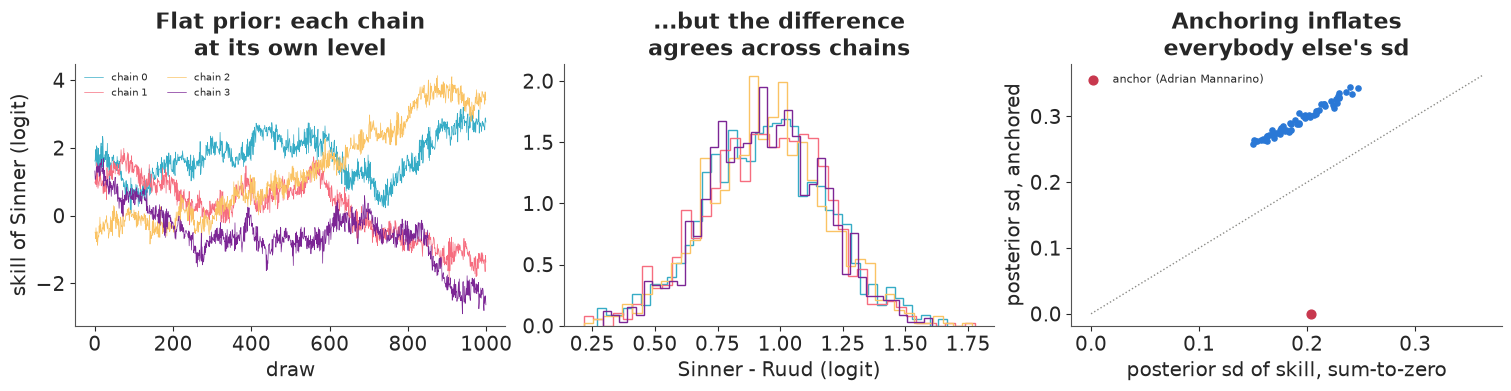

In [7]:
th_z, th_a = draws(id_bt, "theta"), draws(id_anchor, "theta")
d_z, d_a = th_z[:, ks] - th_z[:, kr], th_a[:, ks] - th_a[:, kr]
print(f"Sinner - Ruud: sum-to-zero {d_z.mean():.2f} +- {d_z.std():.2f} | anchored "
      f"{d_a.mean():.2f} +- {d_a.std():.2f} | flat {diff_f.values.mean():.2f} +- {diff_f.values.std():.2f}")
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for c in range(4):
    axes[0].plot(th_f.isel(player=ks, chain=c).values, lw=0.5, label=f"chain {c}")
axes[0].set(xlabel="draw", ylabel="skill of Sinner (logit)", title="Flat prior: each chain\nat its own level")
axes[0].legend(fontsize=7, ncols=2)
for c in range(4):
    axes[1].hist(diff_f.isel(chain=c).values, bins=40, histtype="step", density=True)
axes[1].set(xlabel="Sinner - Ruud (logit)", title="...but the difference\nagrees across chains")
sd_z, sd_a = th_z.std(axis=0), th_a.std(axis=0)
axes[2].scatter(sd_z, sd_a, s=14, color=BLUE)
axes[2].scatter(sd_z[k_anchor], sd_a[k_anchor], s=40, color=RED, label=f"anchor ({ANCHOR})")
mx = max(sd_z.max(), sd_a.max()) * 1.05
axes[2].plot([0, mx], [0, mx], color=GREY, lw=1, ls=":")
axes[2].set(xlabel="posterior sd of skill, sum-to-zero", ylabel="posterior sd, anchored",
            title="Anchoring inflates\neverybody else's sd")
axes[2].legend(fontsize=8);

The flat-prior fit is a textbook non-identification: skills with r_hat up to 1.9 and a bulk ESS of
6, chains drifting to their own levels (left) - and yet zero divergences, and an r_hat of 1.00 for
any *difference* (middle), which is all the data speak about. The anchored model is identified,
but its uncertainties answer "how good is X compared with Mannarino?", so every one of them is
inflated by Mannarino's own uncertainty (right: all points above the diagonal, sds of 0.26-0.34
instead of 0.15-0.25) while the anchor gets a misleading sd of zero. The sum-to-zero version gives
uncertainties relative to the field, which is what a ranking needs. The flat and anchored fits
agree exactly on differences (Sinner - Ruud 0.94); the hierarchical sum-to-zero fit shrinks them a
little (0.82) - that is the hierarchical prior at work, not the constraint. From here on we use it.

In [8]:
print(az.summary(id_bt, var_names=["sigma_theta"], round_to=3))
thm = th_z.mean(axis=0)
o = np.argsort(-thm)[:12]
print("top 12 by posterior mean skill (Jan 2021 - Jun 2025, all surfaces):")
for k in o:
    print(f"  {players[k]:26s} {thm[k]:5.2f} +- {th_z[:, k].std():.2f}")

              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
sigma_theta  0.636  0.068     0.535     0.749  4771.575  3457.981  1.002   

             mcse_mean  mcse_sd  
sigma_theta      0.001    0.001  
top 12 by posterior mean skill (Jan 2021 - Jun 2025, all surfaces):
  Novak Djokovic              1.85 +- 0.20
  Carlos Alcaraz              1.58 +- 0.17
  Jannik Sinner               1.45 +- 0.17
  Daniil Medvedev             1.08 +- 0.15
  Stefanos Tsitsipas          0.95 +- 0.16
  Alexander Zverev            0.91 +- 0.15
  Casper Ruud                 0.63 +- 0.15
  Taylor Fritz                0.62 +- 0.16
  Andrey Rublev               0.61 +- 0.15
  Jack Draper                 0.59 +- 0.21
  Grigor Dimitrov             0.54 +- 0.17
  Matteo Berrettini           0.41 +- 0.20


$\sigma_\theta \approx 0.64$ logits: of two players one standard deviation apart, the better one
wins about 65% of the time. The static table puts Djokovic first, ahead of Alcaraz and Sinner.
Averaged over four and a half years it rewards being excellent throughout, and it cannot see that
Sinner (or Alcaraz) ended the period much stronger than he started. Section A5 fixes that.

## A3 · Surfaces as partial pooling

Clay slows the ball and rewards long rallies; grass is fast and rewards serving. Each player
gets a surface deviation around their overall skill,

$$\theta_{i,s} = \theta_i + \tau\, z_{i,s}, \qquad z_{\cdot,s} \sim \text{ZeroSumNormal}$$

(zero-sum over players on each surface, for the same identification reason as before). The
spread $\tau$ is learned: if players did not differ by surface, it would shrink to 0 and every
deviation with it. Grass has few matches (a short season), so partial pooling matters most there.

In [9]:
with pm.Model(coords=coords) as m_sf:
    sigma_theta = pm.HalfNormal("sigma_theta", 1.0)
    tau = pm.HalfNormal("tau_surface", 0.5)
    theta = pm.ZeroSumNormal("theta", sigma=sigma_theta, dims="player")
    dz = pm.ZeroSumNormal("delta_z", dims=("surface", "player"), n_zerosum_axes=1)
    skill = pm.Deterministic("skill", theta[None, :] + tau * dz, dims=("surface", "player"))
    pm.Bernoulli("y", logit_p=skill[s_tr, ya_tr] - skill[s_tr, yb_tr], observed=tr.y.to_numpy())
id_sf = fit(m_sf, "surface model")
print(f"{worst(id_sf, ['theta', 'delta_z'])}")
print(az.summary(id_sf, var_names=["sigma_theta", "tau_surface"], round_to=3))

surface model: 6 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.005, min bulk ESS 2904
              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
sigma_theta  0.627  0.073     0.521     0.754  4026.629  3252.722  1.000   
tau_surface  0.279  0.059     0.189     0.372   930.100  1415.490  1.006   

             mcse_mean  mcse_sd  
sigma_theta      0.001    0.001  
tau_surface      0.002    0.001  


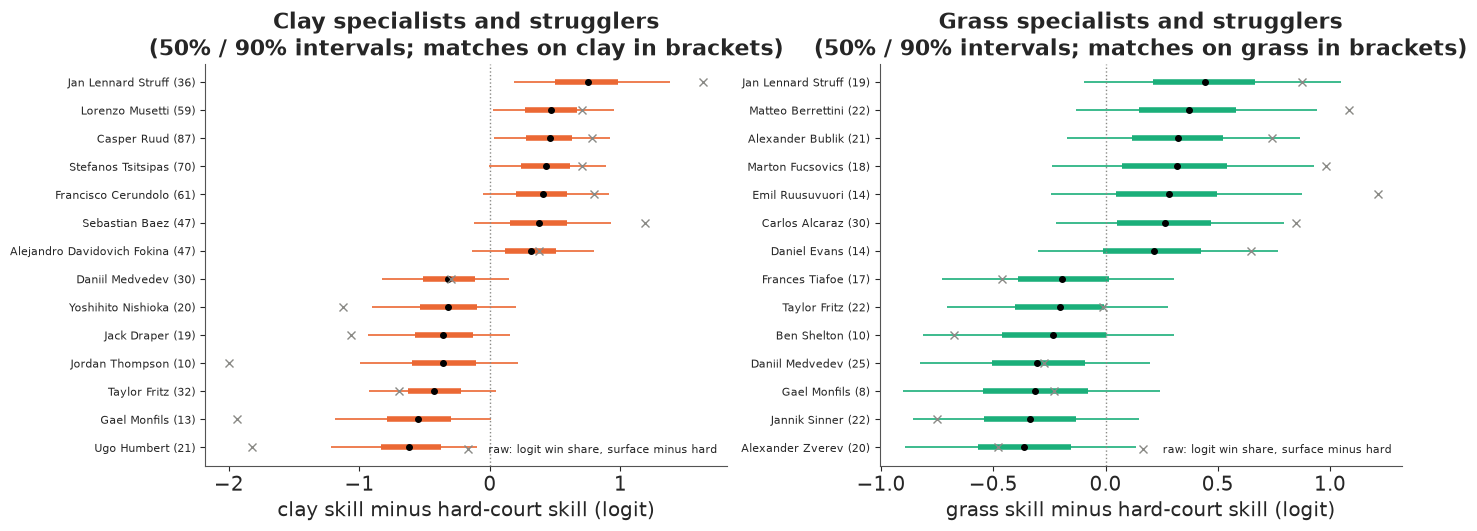

In [10]:
dev = draws(id_sf, "skill") - draws(id_sf, "theta")[:, None, :]          # tau * z
n_surf = np.array([[((tr.a == k) | (tr.b == k))[tr.s == s].sum() for k in range(NP)] for s in range(3)])
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, s, name in [(axes[0], 1, "Clay"), (axes[1], 2, "Grass")]:
    gap = dev[:, s, :] - dev[:, 0, :]                                  # surface minus hard
    mean_gap = gap.mean(axis=0)
    sel = np.r_[np.argsort(mean_gap)[:7], np.argsort(mean_gap)[-7:]]
    q = np.quantile(gap[:, sel], [0.05, 0.25, 0.75, 0.95], axis=0)
    yy = np.arange(len(sel))
    ax.hlines(yy, q[0], q[3], color=SURF_COL[name], lw=1.2)
    ax.hlines(yy, q[1], q[2], color=SURF_COL[name], lw=4)
    ax.plot(mean_gap[sel], yy, "o", color="k", ms=4)
    raw = []
    for k in sel:  # raw win share on the surface minus on hard, for comparison
        def ws(si):
            mk = ((tr.a == k) | (tr.b == k)) & (tr.s == si)
            won = ((tr.a == k) & (tr.y == 1)) | ((tr.b == k) & (tr.y == 0))
            return won[mk].mean()
        raw.append(special.logit(np.clip(ws(s), 0.03, 0.97)) - special.logit(np.clip(ws(0), 0.03, 0.97)))
    ax.plot(raw, yy, "x", color=GREY, ms=6, label="raw: logit win share, surface minus hard")
    ax.set_yticks(yy, [f"{players[k]} ({n_surf[s, k]})" for k in sel], fontsize=8)
    ax.axvline(0, color=GREY, lw=1, ls=":")
    ax.set(xlabel=f"{name.lower()} skill minus hard-court skill (logit)",
           title=f"{name} specialists and strugglers\n(50% / 90% intervals; matches on {name.lower()} in brackets)")
    ax.legend(fontsize=8, loc="lower right");

$\tau \approx 0.28$ logits (89% interval 0.19-0.37) is clearly away from zero: surfaces matter, at
a bit under half the spread in overall skill. The pooled estimates (dots) are pulled towards zero
compared with the raw win-share differences (crosses), most of all for players with few matches
on the surface - on grass that is 8-30 matches in four and a half years. The specialists are
recognisable: Ruud, Musetti, Tsitsipas, Cerundolo, Baez and Davidovich Fokina better on clay than
on hard courts; the big servers Berrettini and Bublik, and Alcaraz, better on grass; Medvedev,
Fritz and Monfils worse on both. The panels show surface minus *hard*, so a player who is weak on
hard courts (Struff) tops both lists.

## A4 · Does the model reproduce the data?

A posterior predictive check compares the data with data replicated from the fitted model. The
obvious first statistic is each player's number of wins. But in Bradley-Terry a player's win
total is (given the opponents) the **sufficient statistic** for his skill: the fit adjusts each
$\theta_i$ until the expected wins match the observed ones, so this check cannot fail. A check
is only informative if it looks at something the model was *not* tuned to reproduce. Here is one
the static model has no parameter for: **how much each player's win share changed** between the
first two years (2021-2022) and the last eighteen months (2024 to June 2025).

win totals outside their 90% predictive interval:  0 of 60
change in win share outside its 90% interval:       16 of 56 players with 10+ matches in both periods (about 6 expected if the model were right)


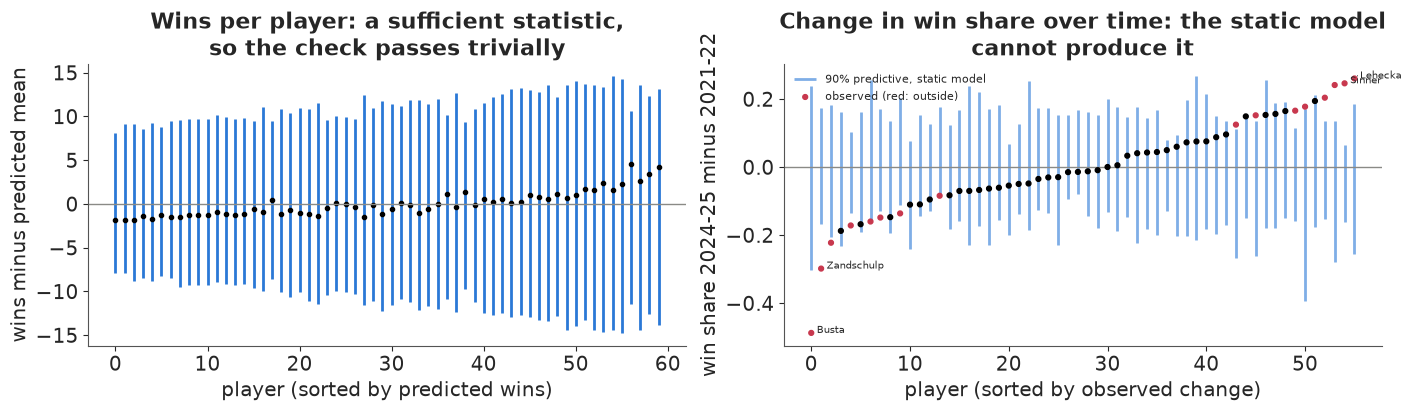

In [11]:
with m_sf:
    pp = pm.sample_posterior_predictive(id_sf, random_seed=RANDOM_SEED, progressbar=False)
y_rep = pp.posterior_predictive["y"].values.reshape(-1, len(tr))
sk_draw = draws(id_sf, "skill")                                   # (draws, surface, player)
won_a = np.zeros((NP, len(tr)))
won_a[ya_tr, np.arange(len(tr))] = 1
won_b = np.zeros((NP, len(tr)))
won_b[yb_tr, np.arange(len(tr))] = 1
wins_rep = y_rep @ won_a.T + (1 - y_rep) @ won_b.T                   # (draws, players)
wins_obs = tr.y.to_numpy() @ won_a.T + (1 - tr.y.to_numpy()) @ won_b.T
early = (tr.date < "2023-01-01").to_numpy()
late = (tr.date >= "2024-01-01").to_numpy()


def share_change(y):
    """Per player: win share in 2024-Jun 2025 minus win share in 2021-2022 (y: (..., matches))."""
    def share(mask):
        wins = y[..., mask] @ won_a[:, mask].T + (1 - y[..., mask]) @ won_b[:, mask].T
        return wins / (won_a + won_b)[:, mask].sum(axis=1)
    return share(late) - share(early)


played = won_a + won_b
both = (played[:, early].sum(axis=1) >= 10) & (played[:, late].sum(axis=1) >= 10)
keep_p = np.where(both)[0]                  # players with 10+ matches in both periods
chg_obs = share_change(tr.y.to_numpy().astype(float))[keep_p]
chg_static = share_change(y_rep)[:, keep_p]
lo_w, hi_w = np.quantile(wins_rep, [0.05, 0.95], axis=0)
lo_c, hi_c = np.quantile(chg_static, [0.05, 0.95], axis=0)
NK = len(keep_p)
print(f"win totals outside their 90% predictive interval:  {np.sum((wins_obs < lo_w) | (wins_obs > hi_w))} of {NP}")
print(f"change in win share outside its 90% interval:       {np.sum((chg_obs < lo_c) | (chg_obs > hi_c))} of {NK}"
      f" players with 10+ matches in both periods (about {0.1 * NK:.0f} expected if the model were right)")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
oo = np.argsort(wins_rep.mean(axis=0))
axes[0].vlines(np.arange(NP), (lo_w - wins_rep.mean(0))[oo], (hi_w - wins_rep.mean(0))[oo], color=BLUE, lw=2)
axes[0].plot(np.arange(NP), (wins_obs - wins_rep.mean(0))[oo], "o", color="k", ms=3)
axes[0].axhline(0, color=GREY, lw=1)
axes[0].set(xlabel="player (sorted by predicted wins)", ylabel="wins minus predicted mean",
            title="Wins per player: a sufficient statistic,\nso the check passes trivially")
oc = np.argsort(chg_obs)
out = (chg_obs < lo_c) | (chg_obs > hi_c)
axes[1].vlines(np.arange(NK), lo_c[oc], hi_c[oc], color=BLUE, lw=2, alpha=0.6, label="90% predictive, static model")
axes[1].scatter(np.arange(NK), chg_obs[oc], s=12, c=np.where(out[oc], RED, "k"), zorder=3,
                label="observed (red: outside)")
axes[1].axhline(0, color=GREY, lw=1)
for j in [0, 1, NK - 2, NK - 1]:
    axes[1].annotate(players[keep_p[oc[j]]].split()[-1], (j, chg_obs[oc[j]]), fontsize=7,
                     xytext=(4, 0), textcoords="offset points")
axes[1].set(xlabel="player (sorted by observed change)", ylabel="win share 2024-25 minus 2021-22",
            title="Change in win share over time: the static model\ncannot produce it")
axes[1].legend(fontsize=8);

The wins check is perfect, which is exactly why it is useless. The time check is not: far more
players than the expected handful sit outside the static model's 90% interval, at both ends -
players who rose (like Sinner) and players who declined. The static model averages a player over
four and a half years; the data say skills moved. Time is next.


## A5 · Dynamic skill: a random walk per player

Players improve, peak and decline. The dynamic model lets each skill take a Gaussian random-walk
step every quarter,

$$\theta_{i,t} = \theta_{i,t-1} + \sigma_{\text{rw}}\, z_{i,t}, \qquad z_{\cdot, t} \sim
\text{ZeroSumNormal},$$

still with sum-to-zero across players at every time (otherwise the whole field could drift
together, unidentified). This is the Bayesian relative of **Glicko** (Glickman 1999) and
**TrueSkill Through Time** (Dangauthier et al., NIPS 2007): the rating has uncertainty, the uncertainty
grows between matches, and - unlike an online filter - every result informs the skill *before and
after* it, because we condition on the whole history (a smoother, not a filter). The random-walk
scale $\sigma_\text{rw}$ plays the role of Elo's learning rate $K$, but it is estimated from the
data rather than tuned. The surface deviations from A3 are kept, constant over time.

The steps are written non-centred ($z$ standard normal, scaled by $\sigma_\text{rw}$): with about
seven matches per player per quarter, each step is weakly informed and non-centred is the
usual right choice.

In [12]:
def dynamic_model(df, n_q):
    """Bradley-Terry with quarterly random-walk skills and surface deviations."""
    c = {"player": players, "surface": SURFACES, "quarter": np.arange(n_q)}
    with pm.Model(coords=c) as m:
        sigma_theta = pm.HalfNormal("sigma_theta", 1.0)
        sigma_rw = pm.HalfNormal("sigma_rw", 0.3)
        tau = pm.HalfNormal("tau_surface", 0.5)
        theta0 = pm.ZeroSumNormal("theta0", sigma=sigma_theta, dims="player")
        z = pm.ZeroSumNormal("z_rw", dims=("quarter", "player"), n_zerosum_axes=1)
        steps = pt.concatenate([pt.zeros((1, NP)), sigma_rw * z[1:]], axis=0)
        th_q = pm.Deterministic("theta_q", theta0[None, :] + pt.cumsum(steps, axis=0),
                                dims=("quarter", "player"))
        dz = pm.ZeroSumNormal("delta_z", dims=("surface", "player"), n_zerosum_axes=1)
        q, a, b, s = (df[k].to_numpy() for k in ["quarter", "a", "b", "s"])
        eta = th_q[q, a] - th_q[q, b] + tau * (dz[s, a] - dz[s, b])
        pm.Bernoulli("y", logit_p=eta, observed=df.y.to_numpy())
    return m


NQ_TR = tr.quarter.max() + 1
m_dyn = dynamic_model(tr, NQ_TR)
id_dyn = fit(m_dyn, "dynamic model")
print(worst(id_dyn, ["theta_q", "delta_z"]))
print(az.summary(id_dyn, var_names=["sigma_theta", "sigma_rw", "tau_surface"], round_to=3))
with m_dyn:
    pp_dyn = pm.sample_posterior_predictive(id_dyn, random_seed=RANDOM_SEED, progressbar=False)
chg_dyn = share_change(pp_dyn.posterior_predictive["y"].values.reshape(-1, len(tr)))[:, keep_p]
lo_d, hi_d = np.quantile(chg_dyn, [0.05, 0.95], axis=0)
print(f"the A4 time check again - change in win share outside the 90% interval: "
      f"static {np.sum((chg_obs < lo_c) | (chg_obs > hi_c))}, dynamic {np.sum((chg_obs < lo_d) | (chg_obs > hi_d))} of {NK}")
del pp, pp_dyn, y_rep

dynamic model: 17 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.005, min bulk ESS 2143
              mean     sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  \
sigma_theta  0.568  0.086     0.437     0.707  1396.201  1701.510  1.002   
sigma_rw     0.154  0.027     0.113     0.197   869.957  1482.094  1.004   
tau_surface  0.289  0.062     0.191     0.387  1119.863  1591.683  1.000   

             mcse_mean  mcse_sd  
sigma_theta      0.002    0.001  
sigma_rw         0.001    0.000  
tau_surface      0.002    0.001  


the A4 time check again - change in win share outside the 90% interval: static 16, dynamic 1 of 56


### Plain Elo on the same players

Elo updates two ratings after each match by $K \times$ (result $-$ expected result), with expected
result $1/(1 + 10^{(r_b - r_a)/400})$. On the logit scale a rating difference of $\Delta$ Elo points
is $\Delta \ln 10 / 400$ logits, so Elo and Bradley-Terry skills can be drawn on one axis. We tune
$K$ the way Elo users do, by the one-step-ahead log score over the fitting period (ignoring the
first quarter of matches while ratings settle).

In [13]:
def elo_run(df, K, init=None):
    """Sequential Elo over df; returns final ratings, pre-match P(a wins) and rating history."""
    r = np.full(NP, 1500.0) if init is None else init.copy()
    probs, hist = np.empty(len(df)), np.empty((len(df), NP))
    for i, (a, b, y) in enumerate(zip(df.a.to_numpy(), df.b.to_numpy(), df.y.to_numpy())):
        p = 1 / (1 + 10 ** ((r[b] - r[a]) / 400))
        probs[i] = p
        r[a] += K * (y - p)
        r[b] -= K * (y - p)
        hist[i] = r
    return r, probs, hist


burn = len(tr) // 4
k_grid = [8, 12, 16, 20, 24, 32, 40]
k_score = []
for K in k_grid:
    _, p_seq, _ = elo_run(tr, K)
    yy = tr.y.to_numpy()[burn:]
    k_score.append(np.mean(yy * np.log(p_seq[burn:]) + (1 - yy) * np.log(1 - p_seq[burn:])))
K_ELO = k_grid[int(np.argmax(k_score))]
print("K:", k_grid)
print("one-step log score per match:", np.round(k_score, 4), f"-> K = {K_ELO}")
elo_end, _, elo_hist = elo_run(tr, K_ELO)

K: [8, 12, 16, 20, 24, 32, 40]
one-step log score per match: [-0.6346 -0.6271 -0.6237 -0.6224 -0.6224 -0.6244 -0.6277] -> K = 24


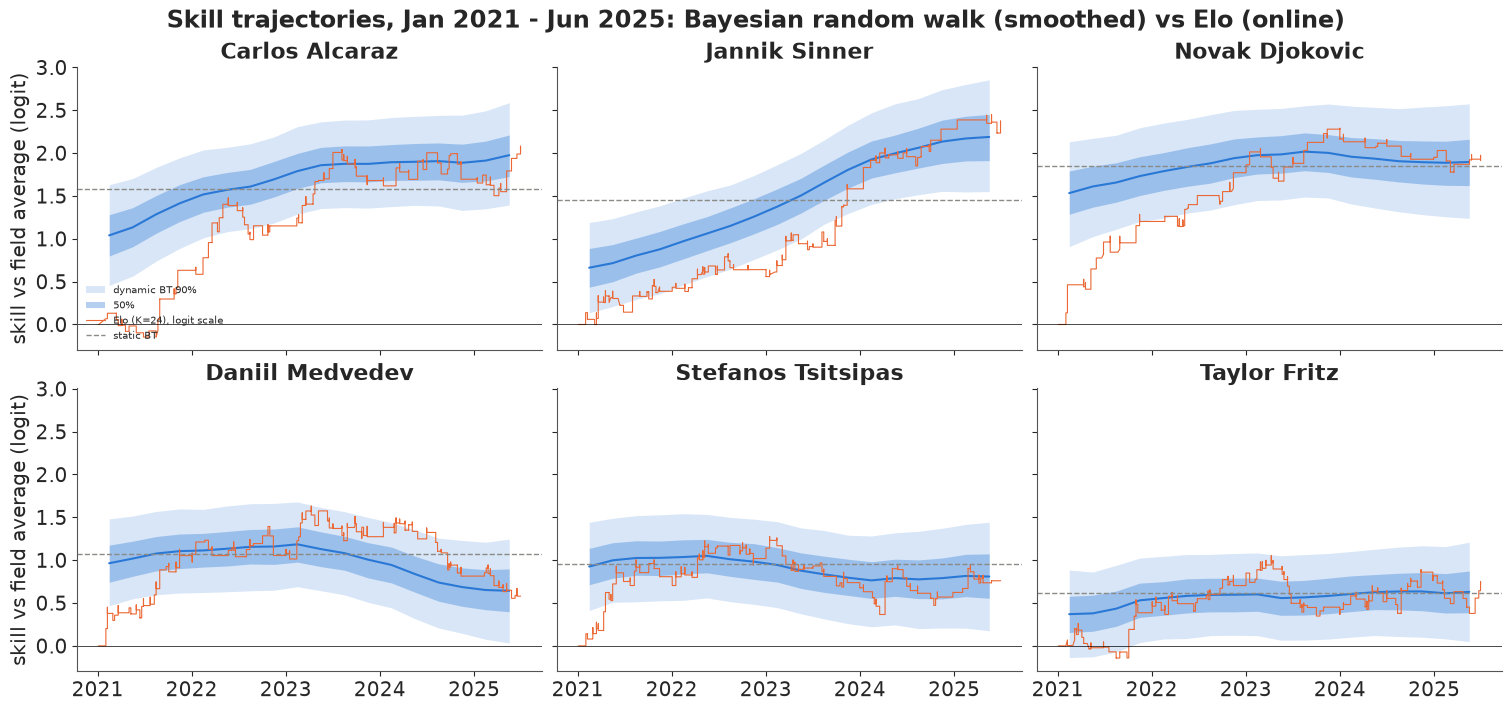

In [14]:
SHOW = ["Carlos Alcaraz", "Jannik Sinner", "Novak Djokovic", "Daniil Medvedev", "Stefanos Tsitsipas",
        "Taylor Fritz"]
th_q = draws(id_dyn, "theta_q")                                   # (draws, quarter, player)
q_mid = pd.Timestamp("2021-02-15") + pd.to_timedelta(np.arange(NQ_TR) * 91.3, unit="D")
elo_logit = (elo_hist - elo_hist.mean(axis=1, keepdims=True)) * np.log(10) / 400
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, SHOW):
    k = pidx.get_loc(name)
    q = np.quantile(th_q[:, :, k], [0.05, 0.25, 0.75, 0.95], axis=0)
    ax.fill_between(q_mid, q[0], q[3], color=BLUE, alpha=0.18, lw=0, label="dynamic BT 90%")
    ax.fill_between(q_mid, q[1], q[2], color=BLUE, alpha=0.35, lw=0, label="50%")
    ax.plot(q_mid, th_q[:, :, k].mean(axis=0), color=BLUE, lw=1.5)
    ax.plot(tr.date, elo_logit[:, k], color=ORANGE, lw=0.8, label=f"Elo (K={K_ELO}), logit scale")
    ax.axhline(th_z[:, k].mean(), color=GREY, ls="--", lw=1, label="static BT")
    ax.set_title(name)
    ax.axhline(0, color="k", lw=0.5)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0, 0].legend(fontsize=7, loc="lower left")
for ax in axes[:, 0]:
    ax.set_ylabel("skill vs field average (logit)")
fig.suptitle("Skill trajectories, Jan 2021 - Jun 2025: Bayesian random walk (smoothed) vs Elo (online)");

First, the check that failed in A4: with skills free to move, the change in win share between
2021-22 and 2024-25 falls outside the 90% predictive interval for 1 of 56 players, against 16 for
the static model.

The trajectories tell the story of the period: Sinner climbing steadily from a promising 0.7 to
the top, Alcaraz rising through 2021-22 and then holding level, Djokovic flat near the top
throughout, Medvedev peaking in 2023 and fading, Tsitsipas drifting down. Elo tells the same story
with a jagged, lagging line: every rating starts at 1500 (the field average), so Elo needs about
a year to discover that Djokovic is good, and afterwards it only moves after results and never
looks back. The Bayesian trajectory is smoothed (a 2022 result informs the 2021 skill), carries
an interval, and has a learned volatility: $\sigma_\text{rw} \approx 0.15$ logits per quarter,
about 0.3 a year, against a between-player spread of about 0.57.

## A6 · Predicting the next twelve months

The acid test for a rating system is prediction. Every model is frozen at the end of June 2025 and
asked for the win probability of each held-out match from July 2025 to Roland Garros 2026. For
the dynamic model, a match $h$ quarters after the last fitted one adds the random-walk
uncertainty $\sigma_\text{rw}\sqrt{h}$ to each player's skill before averaging the win
probability over the posterior. We also score **Elo updated online** through the test year (which
uses results the frozen models do not see), a **ranking-points** model (a logistic regression on
the log ratio of the players' ATP points at the time of the match, fitted on the training
matches - the points are current, so this one also sees the test year indirectly), and a coin.
Scores are per match: log score (higher is better, a coin gets
$\ln 0.5 = -0.693$) and Brier score (lower is better, a coin gets 0.25).

In [15]:
ta, tb, ts = te.a.to_numpy(), te.b.to_numpy(), te.s.to_numpy()
y_te = te.y.to_numpy()
pred = {}
pred["Bradley-Terry, static"] = special.expit(th_z[:, ta] - th_z[:, tb]).mean(axis=0)
pred["BT + surface, static"] = special.expit(sk_draw[:, ts, ta] - sk_draw[:, ts, tb]).mean(axis=0)
th_last = th_q[:, -1, :]
dz_d, tau_d = draws(id_dyn, "delta_z"), draws(id_dyn, "tau_surface")[:, None]
srw_d = draws(id_dyn, "sigma_rw")[:, None]
h = (te.quarter.to_numpy() - (NQ_TR - 1))
eta_te = th_last[:, ta] - th_last[:, tb] + tau_d * (dz_d[:, ts, ta] - dz_d[:, ts, tb])
rng_a6 = np.random.default_rng(6)
eta_te = eta_te + rng_a6.normal(size=eta_te.shape) * srw_d * np.sqrt(2 * h)[None, :]
pred["dynamic BT + surface"] = special.expit(eta_te).mean(axis=0)
pred[f"Elo (K={K_ELO}), frozen"] = 1 / (1 + 10 ** ((elo_end[tb] - elo_end[ta]) / 400))
_, pred[f"Elo (K={K_ELO}), updated online"], _ = elo_run(te, K_ELO, init=elo_end)


def log_points_ratio(df):
    pa = np.where(df.y == 1, df.winner_rank_points, df.loser_rank_points)
    pb = np.where(df.y == 1, df.loser_rank_points, df.winner_rank_points)
    return np.log(pa.astype(float)) - np.log(pb.astype(float))


x_tr, x_te = log_points_ratio(tr), log_points_ratio(te)
ok = np.isfinite(x_tr)
nll = lambda beta: -np.sum(np.log(special.expit((2 * tr.y.to_numpy()[ok] - 1) * beta * x_tr[ok])))
beta_pts = optimize.minimize_scalar(nll, bounds=(0, 5), method="bounded").x
pred["ATP ranking points"] = np.where(np.isfinite(x_te), special.expit(beta_pts * np.nan_to_num(x_te)), 0.5)
pred["coin"] = np.full(len(te), 0.5)

ll = {k: y_te * np.log(p) + (1 - y_te) * np.log(1 - p) for k, p in pred.items()}
ref = ll["dynamic BT + surface"]
rows = []
for k, p in pred.items():
    dlt = ll[k] - ref
    rows.append({"model": k, "log score / match": ll[k].mean(), "Brier": np.mean((p - y_te) ** 2),
                 "accuracy": np.mean((p > 0.5) == y_te),
                 "log score minus dynamic": dlt.sum(), "se of difference": dlt.std() * np.sqrt(len(dlt))})
score_tab = pd.DataFrame(rows).set_index("model")
print(f"{len(te)} held-out matches, Jul 2025 to Roland Garros 2026; ATP points model: logit = {beta_pts:.2f} x log(points ratio)")
print(score_tab.round(3).to_string())

439 held-out matches, Jul 2025 to Roland Garros 2026; ATP points model: logit = 0.72 x log(points ratio)
                            log score / match  Brier  accuracy  log score minus dynamic  se of difference
model                                                                                                    
Bradley-Terry, static                  -0.602  0.208     0.663                   -1.964             3.224
BT + surface, static                   -0.606  0.210     0.661                   -3.586             2.981
dynamic BT + surface                   -0.598  0.208     0.645                    0.000             0.000
Elo (K=24), frozen                     -0.593  0.206     0.654                    2.014             2.062
Elo (K=24), updated online             -0.583  0.202     0.667                    6.306             3.518
ATP ranking points                     -0.611  0.211     0.661                   -5.965             5.864
coin                                   -0.693  

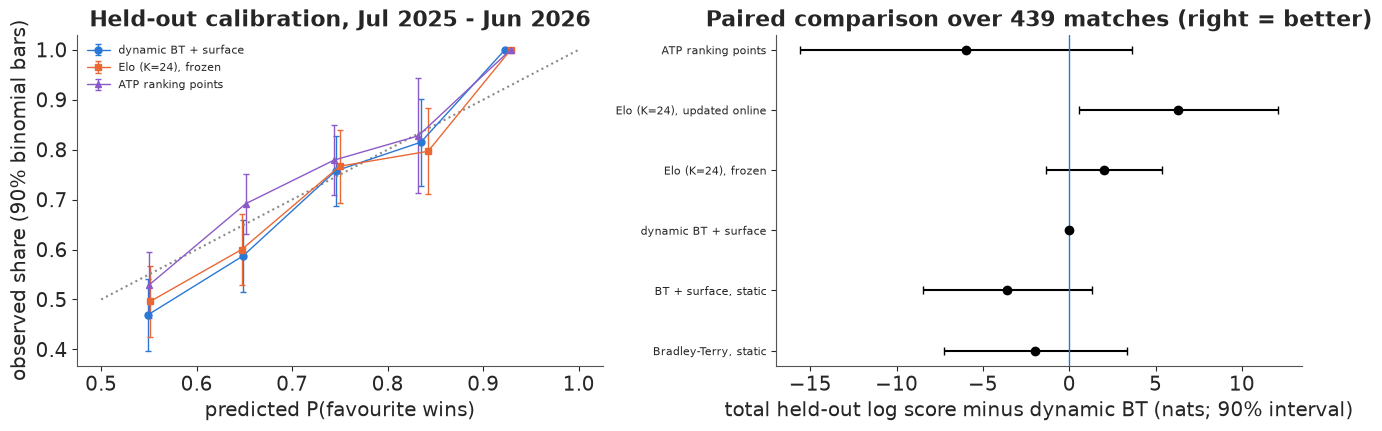

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
bins = np.linspace(0.5, 1, 6)
for name, col, mk in [("dynamic BT + surface", BLUE, "o"), (f"Elo (K={K_ELO}), frozen", ORANGE, "s"),
                      ("ATP ranking points", PURPLE, "^")]:
    p = pred[name]
    pf, yf = np.maximum(p, 1 - p), np.where(p >= 0.5, y_te, 1 - y_te)
    cb = pd.DataFrame({"p": pf, "y": yf, "bin": np.digitize(pf, bins)}).groupby("bin").agg(
        p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
    se = np.sqrt(cb.y * (1 - cb.y) / cb.n)
    axes[0].errorbar(cb.p, cb.y, yerr=1.64 * se, fmt=mk + "-", color=col, ms=5, lw=1, capsize=2, label=name)
axes[0].plot([0.5, 1], [0.5, 1], color=GREY, ls=":")
axes[0].set(xlabel="predicted P(favourite wins)", ylabel="observed share (90% binomial bars)",
            title="Held-out calibration, Jul 2025 - Jun 2026")
axes[0].legend(fontsize=8)
dd = score_tab.drop(index="coin")
yy = np.arange(len(dd))
axes[1].errorbar(dd["log score minus dynamic"], yy, xerr=1.64 * dd["se of difference"], fmt="o", color="k",
                 capsize=3)
axes[1].axvline(0, color=BLUE, lw=1)
axes[1].set_yticks(yy, dd.index, fontsize=8)
axes[1].set(xlabel="total held-out log score minus dynamic BT (nats; 90% interval)",
            title=f"Paired comparison over {len(te)} matches (right = better)");

**What the scoreboard says.** Every model beats the coin by 36-48 nats over 439 matches, and
the three plotted are reasonably calibrated on the held-out year. Among the serious models the
differences are small against their standard errors. Frozen Elo scores 2.0 nats better than the
dynamic model in total (se 2.1) - a tie. ATP ranking points are about 6 nats worse (se 5.9) and
the static models 2-4 nats worse, none of it conclusive. Only online Elo, which learns from the
test-year results, is clearly better (+6.3, se 3.5), as it should be: a fair Bayesian counterpart
would refit (or filter) as results arrive. Accuracy (share of favourites that won) ranks the
models differently from the log score - it ignores how confident each prediction was and is the
noisiest of the three scores.

So on *point predictions* a tuned Elo is a hard baseline on this data, and the surface terms buy
nothing measurable in 439 matches. What the Bayesian model adds is what Elo cannot give: a
volatility learned rather than tuned, uncertainty on every skill and every prediction, surface
effects with honest shrinkage, and - next - answers to questions about rankings rather than
single matches.

## A7 · Decisions: who is the best, and who wins a tournament?

For current answers we refit the dynamic model on *all* matches up to Roland Garros 2026 (same 60
players; newcomers who were not among them before July 2025 are still missing).

In [17]:
NQ_ALL = tm.quarter.max() + 1
id_now = fit(dynamic_model(tm, NQ_ALL), "dynamic model, all data to Jun 2026")
print(worst(id_now, ["theta_q", "delta_z"]))
th_now = draws(id_now, "theta_q")[:, -1, :]                        # skill in Q2 2026
dz_now, tau_now = draws(id_now, "delta_z"), draws(id_now, "tau_surface")[:, None]
S = th_now.shape[0]
p_best = np.bincount(th_now.argmax(axis=1), minlength=NP) / S
ranks = (-th_now).argsort(axis=1).argsort(axis=1) + 1              # rank 1 = best, per draw
top20 = np.argsort(-th_now.mean(axis=0))[:20]
print("top 5 by posterior mean skill, Q2 2026 (all surfaces):")
for k in np.argsort(-th_now.mean(axis=0))[:5]:
    print(f"  {players[k]:24s} P(best) {p_best[k]:.3f}   rank median {np.median(ranks[:, k]):.0f}, "
          f"90% {np.quantile(ranks[:, k], [0.05, 0.95]).astype(int)}")

dynamic model, all data to Jun 2026: 18 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.006, min bulk ESS 2585
top 5 by posterior mean skill, Q2 2026 (all surfaces):
  Jannik Sinner            P(best) 0.795   rank median 1, 90% [1 2]
  Carlos Alcaraz           P(best) 0.141   rank median 2, 90% [1 3]
  Novak Djokovic           P(best) 0.064   rank median 3, 90% [1 5]
  Casper Ruud              P(best) 0.000   rank median 8, 90% [ 4 22]
  Jack Draper              P(best) 0.000   rank median 8, 90% [ 4 26]


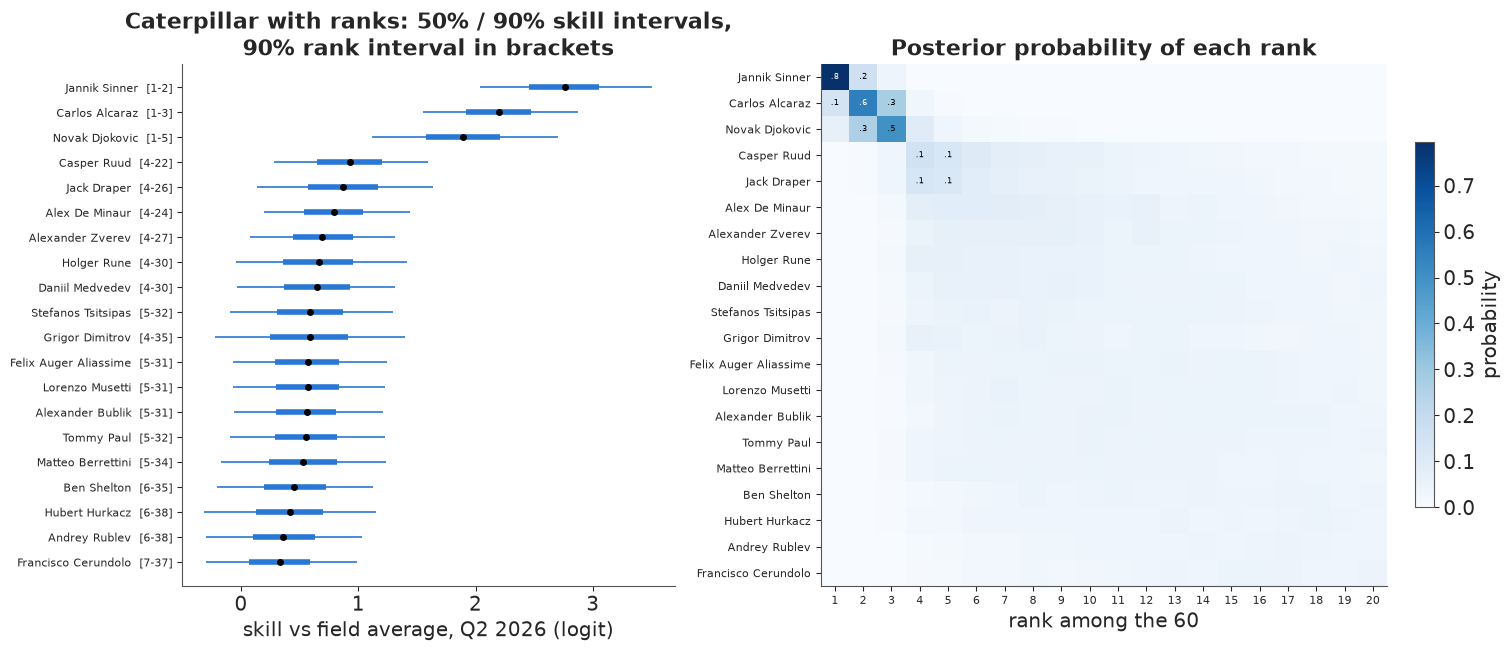

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.4), width_ratios=[1, 1.15])
yy = np.arange(20)[::-1]
q = np.quantile(th_now[:, top20], [0.05, 0.25, 0.75, 0.95], axis=0)
axes[0].hlines(yy, q[0], q[3], color=BLUE, lw=1.2)
axes[0].hlines(yy, q[1], q[2], color=BLUE, lw=4)
axes[0].plot(th_now[:, top20].mean(axis=0), yy, "o", color="k", ms=4)
lab = [f"{players[k]}  [{np.quantile(ranks[:, k], 0.05):.0f}-{np.quantile(ranks[:, k], 0.95):.0f}]" for k in top20]
axes[0].set_yticks(yy, lab, fontsize=8)
axes[0].set(xlabel="skill vs field average, Q2 2026 (logit)",
            title="Caterpillar with ranks: 50% / 90% skill intervals,\n90% rank interval in brackets")
rank_p = np.stack([(ranks[:, top20] == r).mean(axis=0) for r in range(1, 21)], axis=1)
im = axes[1].imshow(rank_p, cmap="Blues", vmin=0, vmax=min(1, rank_p.max()), aspect="auto")
axes[1].set_yticks(np.arange(20), [players[k] for k in top20], fontsize=8)
axes[1].set_xticks(np.arange(20), np.arange(1, 21), fontsize=8)
axes[1].set(xlabel="rank among the 60", title="Posterior probability of each rank")
axes[1].grid(False)
for i in range(20):
    for j in range(20):
        if rank_p[i, j] >= 0.1:
            axes[1].text(j, i, f"{rank_p[i, j]:.1f}".lstrip("0"), ha="center", va="center", fontsize=6,
                         color="white" if rank_p[i, j] > 0.5 else "k")
fig.colorbar(im, ax=axes[1], shrink=0.7, label="probability");

**Who is the best player now?** Sinner, with probability about 0.8; Alcaraz 0.14 and Djokovic 0.06
share the rest. The three are separated from everyone else - their 90% rank intervals stay inside
the top five - but from fourth place down the 90% rank intervals span about 20 to 30 places: Ruud, Draper,
De Minaur, Zverev and the rest are a pack whose order these data cannot settle. A published
ranking list that orders them one by one is reporting noise. The heat map shows the same thing as
probabilities: sharp in the top-left corner, smeared everywhere else.

### A knockout on grass

P(best) is not P(title). A tournament is a chain of matches, each won with probability short of
one, and the draw decides who meets whom. We simulate a 16-player, seeded single-elimination
event on **grass** for the 16 players with the highest grass skill (overall skill plus grass
deviation), one quarter ahead of the last data (so each skill gets one more random-walk step of
uncertainty) - a stylised preview of the grass season after Roland Garros 2026. Each simulation
draws one posterior sample of all skills and plays the whole bracket with it, so the uncertainty
about skills and the luck of each match are both included. (All matches are treated alike; a
best-of-five Grand Slam match favours the stronger player more than the best-of-three matches
that dominate the data.)

In [19]:
rng_ko = np.random.default_rng(7)
srw_now = draws(id_now, "sigma_rw")[:, None]
grass = th_now + tau_now * dz_now[:, 2, :] + rng_ko.normal(size=th_now.shape) * srw_now
seeds = np.argsort(-grass.mean(axis=0))[:16]
bracket = seeds[[0, 15, 7, 8, 4, 11, 3, 12, 5, 10, 2, 13, 6, 9, 1, 14]]   # 1v16, 8v9, ... standard seeding
alive = np.tile(bracket, (S, 1))
reached = {r: np.zeros(NP) for r in ["QF", "SF", "F", "W"]}
for rnd in ["QF", "SF", "F", "W"]:
    a_, b_ = alive[:, 0::2], alive[:, 1::2]
    ga, gb = np.take_along_axis(grass, a_, 1), np.take_along_axis(grass, b_, 1)
    alive = np.where(rng_ko.random(ga.shape) < special.expit(ga - gb), a_, b_)
    np.add.at(reached[rnd], alive.ravel(), 1)
p_best_grass = np.bincount(grass[:, seeds].argmax(axis=1), minlength=16) / S
ko = pd.DataFrame({"seed": np.arange(1, 17), "player": players[seeds],
                   "grass skill": grass[:, seeds].mean(axis=0),
                   "P(best on grass)": p_best_grass,
                   "P(reach SF)": reached["SF"][seeds] / S, "P(reach final)": reached["F"][seeds] / S,
                   "P(title)": reached["W"][seeds] / S}).set_index("seed")
print(ko.round(3).to_string())

                     player  grass skill  P(best on grass)  P(reach SF)  P(reach final)  P(title)
seed                                                                                             
1             Jannik Sinner        2.629             0.596        0.748           0.628     0.413
2            Carlos Alcaraz        2.329             0.274        0.679           0.443     0.248
3            Novak Djokovic        2.012             0.124        0.599           0.328     0.168
4               Jack Draper        0.920             0.002        0.320           0.085     0.024
5            Alex De Minaur        0.811             0.000        0.282           0.072     0.019
6               Casper Ruud        0.770             0.001        0.164           0.050     0.015
7         Matteo Berrettini        0.744             0.000        0.132           0.048     0.011
8          Alexander Bublik        0.702             0.000        0.098           0.047     0.015
9           Daniil M

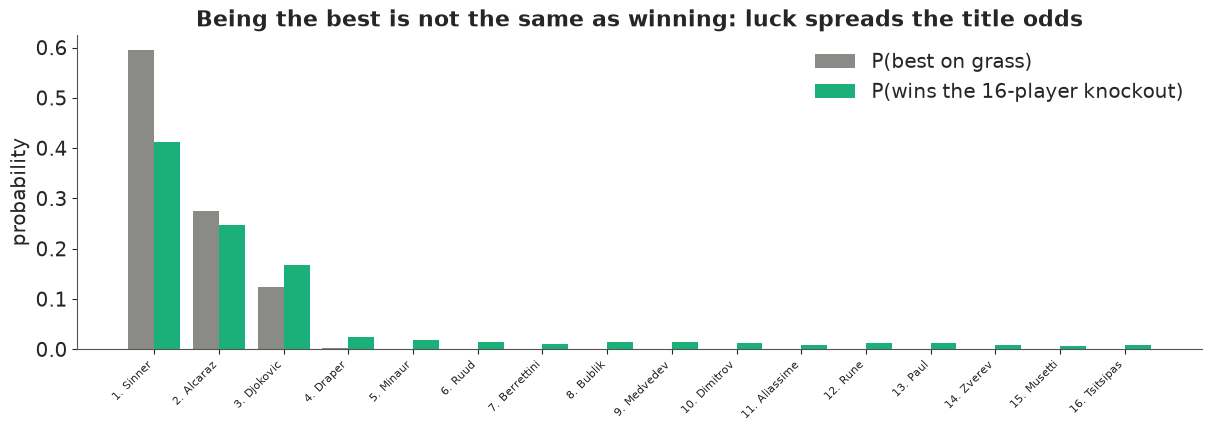

In [20]:
fig, ax = plt.subplots(figsize=(12, 4.2))
xx = np.arange(16)
ax.bar(xx - 0.2, ko["P(best on grass)"], width=0.4, color=GREY, label="P(best on grass)")
ax.bar(xx + 0.2, ko["P(title)"], width=0.4, color=AQUA, label="P(wins the 16-player knockout)")
ax.set_xticks(xx, [f"{i + 1}. {p.split()[-1]}" for i, p in enumerate(ko.player)], rotation=45, ha="right",
              fontsize=8)
ax.set(ylabel="probability", title="Being the best is not the same as winning: luck spreads the title odds");
ax.legend();

The knockout spreads the probability. Sinner is the best grass player with probability about
0.6 but wins the event only about 40% of the time: at posterior-mean skills he beats a low seed
nearly 90% of the time, but a semi-final or final against Alcaraz or Djokovic is closer to 57-65%,
and he must win four in a row. Djokovic's title chance (about 0.17) is *higher* than his chance of
being the best (0.12), and players with essentially no chance of being the best collect 1-2% each.
This is the arithmetic behind upsets: a sport's surprises are not evidence that the ratings are
wrong.

# Part B · Formula 1: ranking whole finishing orders

## B1 · Plackett-Luce as a sequential softmax

A race produces an order, not pairs. The **Plackett-Luce** model builds it like drawing names
from a hat without replacement: the winner is chosen from all $n$ starters with probability
proportional to $e^{s_i}$, second place from the remaining $n-1$ with the same rule, and so on:

$$P(\text{order } o_1, o_2, \dots, o_n) = \prod_{k=1}^{n} \frac{e^{s_{o_k}}}{\sum_{j \ge k} e^{s_{o_j}}}.$$

With two competitors this is exactly Bradley-Terry. Its log is a sum of "strength minus log-sum-exp
of those still in the hat", and the denominators are a *reverse cumulative sum*, so a whole race is
vectorised in a few PyTensor operations. Two properties make it convenient: **(i)** the order of
the top $k$ has a likelihood of its own (just stop the product at $k$), and **(ii)** it is exactly
the order of $s_i + g_i$ with independent standard **Gumbel** noise $g_i$ - the Gumbel-max trick,
which makes simulation a one-liner. Note the word *independent*: each competitor's luck is its own.
That assumption will be tested in B3.

We check the formula before trusting it: the probabilities of all $4! = 24$ orders of four
drivers must sum to 1, and the Gumbel-max simulation must reproduce the formula's probabilities.

In [21]:
def pl_logp(s, valid):
    """Plackett-Luce log-likelihood of each row. s: (races, slots) strengths IN FINISHING ORDER;
    valid: (races, slots) bool, False for padding at the end of a row."""
    s = pt.where(valid, s, -30.0)
    m = pt.max(s, axis=1, keepdims=True)
    tail = pt.cumsum((pt.exp(s - m) * valid)[:, ::-1], axis=1)[:, ::-1]   # sum_{j >= k} exp(s_j - m)
    return pt.sum(pt.where(valid, s - m - pt.log(pt.where(valid, tail, 1.0)), 0.0), axis=1)


s_test = pt.matrix("s")
v_test = pt.matrix("v", dtype="bool")
pl_fn = pytensor.function([s_test, v_test], pl_logp(s_test, v_test))
s4 = np.array([0.8, 0.1, -0.3, -0.6])
orders = list(itertools.permutations(range(4)))
lp_orders = pl_fn(s4[np.array(orders)], np.ones((24, 4), bool))
print(f"sum over all 24 orders of P(order) = {np.exp(lp_orders).sum():.6f}")
g_orders = np.argsort(-(s4 + rng.gumbel(size=(200_000, 4))), axis=1)
freq = pd.Series(map(tuple, g_orders)).value_counts(normalize=True).reindex(orders).fillna(0).to_numpy()
print(f"Gumbel-max vs formula over 24 orders: max |difference| = {np.abs(freq - np.exp(lp_orders)).max():.4f} "
      f"(Monte Carlo sd at the largest p ~ {np.sqrt(np.exp(lp_orders).max() / 200_000):.4f})")

sum over all 24 orders of P(order) = 1.000000


Gumbel-max vs formula over 24 orders: max |difference| = 0.0008 (Monte Carlo sd at the largest p ~ 0.0008)


Both checks pass: the 24 probabilities sum to one, and 200,000 Gumbel-max races match the formula
to within Monte Carlo error.

## The Formula 1 data

In [22]:
data.describe("f1_race_results")
f1 = data.load("f1_race_results")
f1 = f1[f1.position_text != "W"].copy()              # withdrew before the start: not in the race
f1["classified"] = f1.position_text.str.fullmatch(r"\d+")
n_round = f1.groupby("season")["round"].max()
NB = 8                                               # car-development blocks per season (~3 rounds)
f1["block"] = ((f1["round"] - 1) * NB // f1.season.map(n_round)).astype(int)
SEASONS = np.arange(2021, 2026)
teams = {s: sorted(f1[f1.season == s].constructor.unique()) for s in SEASONS}
assert all(len(v) == 10 for v in teams.values())
f1["team_k"] = [teams[s].index(c) for s, c in zip(f1.season, f1.constructor)]
f1["si"] = f1.season - SEASONS[0]
drivers = np.array(sorted(f1.driver_id.unique()))
didx = pd.Index(drivers)
f1["d"] = didx.get_indexer(f1.driver_id)
ds_tab = f1[["driver_id", "season"]].drop_duplicates().sort_values(["season", "driver_id"])
ds_labels = (ds_tab.driver_id + ":" + ds_tab.season.astype(str)).to_numpy()
f1["ds"] = pd.Index(ds_labels).get_indexer(f1.driver_id + ":" + f1.season.astype(str))
sess = f1.groupby(["season", "round", "session"]).agg(n=("d", "size"), n_class=("classified", "sum"))
print(f"{len(sess)} sessions ({(sess.index.get_level_values('session') == 'race').sum()} Grands Prix, "
      f"{(sess.index.get_level_values('session') == 'sprint').sum()} sprints), {len(drivers)} drivers, "
      f"{sum(len(v) for v in teams.values())} team-seasons")
print(f"starters per session {sess.n.min()}-{sess.n.max()}; classified {sess.n_class.min()}-{sess.n_class.max()}; "
      f"{1 - f1.classified.mean():.1%} of starts not classified")
print("why not classified:", f1[~f1.classified].status.value_counts().head(6).to_dict())

f1_race_results: Formula 1 results 2021-2025: 114 Grand Prix races and 24 sprint races, 2,758 rows, one per driver per session. Columns: season, round, session ('race' or 'sprint'; a sprint shares its weekend's round number), race, date, circuit, driver_id, driver_code, driver, constructor (team id), grid (0 = pit-lane start), position (FIA order including non-classified cars), position_text (the classification: a number if classified, R = retired / not classified, D = disqualified, W = withdrew before the start), status (Finished, +1 Lap, Collision, Engine...), laps, points.
  source: Jolpica-F1 API (successor of the Ergast motor-racing API; github.com/jolpica/jolpica-f1), data CC BY-NC-SA 4.0 per its Terms of Use. ASSEMBLED on 2026-09-28 from the paged /ergast/f1/<season>/results.json and /sprint.json endpoints for 2021-2025 (the URL is one page) into one table - keep the cached file in data/.
  url:    https://api.jolpi.ca/ergast/f1/2025/results.json?limit=100
138 sessions (114 Gran

Three modelling choices, each a real decision:

* **Retirements.** About one start in ten ends unclassified - crashes, collisions, engine and
  gearbox failures. A mechanical failure says nothing about pace, and treating a retirement as
  "finished behind everyone" would punish a driver for his gearbox. We rank only the **classified
  finishers** of each session: the likelihood is the Plackett-Luce probability of their order,
  assuming retirements are unrelated to relative pace (a simplification: crashes are partly
  driver error).
* **Driver and car.** The strength of driver $d$ in team $c$ at race $r$ of season $y$ is

  $$s = \underbrace{\beta_d}_{\text{driver}} + \underbrace{\sigma_f\, f_{d,y}}_{\text{driver's
  season form}} + \underbrace{\gamma_{c,y,b(r)}}_{\text{car, block of ~3 rounds}}.$$

  Drivers are compared with the car held fixed mainly through **teammates**, and cars with the
  driver held fixed through drivers who **change teams** (Hamilton to Ferrari, Sainz to Williams,
  and many more between 2021 and 2025).
* **Identification, again.** Plackett-Luce, like Bradley-Terry, only sees differences within a
  session: adding a constant to every car of a season changes nothing. So the car effects are
  **zero-sum over the ten teams within each season and block**, and driver skills are zero-sum
  over drivers. A consequence to keep in mind: a car value means "faster than that season's
  average car", so comparing the 2023 Red Bull with the 2025 McLaren across seasons is not
  something these data can do.

Car development within a season is a random walk over eight blocks of about three rounds; the
first block is the season's starting level. Sprints are included as extra finishing orders.

In [23]:
def f1_arrays(df):
    """Classified finishers of each session in finishing order, padded to 20 slots."""
    df = df[df.classified].sort_values(["season", "round", "session", "position"])
    groups = list(df.groupby(["season", "round", "session"], sort=False))
    J = max(len(g) for _, g in groups)
    arr = {k: np.zeros((len(groups), J), int) for k in ["d", "ds", "si", "block", "team_k"]}
    valid = np.zeros((len(groups), J), bool)
    for i, (_, g) in enumerate(groups):
        valid[i, :len(g)] = True
        for k in arr:
            arr[k][i, :len(g)] = g[k].to_numpy()
    return arr, valid, [key for key, _ in groups]


def f1_model(arr, valid, race_day=False):
    """Plackett-Luce on classified finishing orders: driver + season form + car (random walk
    over blocks). race_day=True adds a shared effect for the two cars of a team in each session."""
    c = {"driver": drivers, "driver_season": ds_labels, "season": SEASONS, "block": np.arange(NB),
         "team": np.arange(10), "session": np.arange(valid.shape[0])}
    with pm.Model(coords=c) as m:
        sigma_driver = pm.HalfNormal("sigma_driver", PRIOR_SD)
        sigma_form = pm.HalfNormal("sigma_form", 0.3)
        sigma_car = pm.HalfNormal("sigma_car", PRIOR_SD)
        sigma_dev = pm.HalfNormal("sigma_dev", 0.3)
        beta = pm.ZeroSumNormal("driver_skill", sigma=sigma_driver, dims="driver")
        form_z = pm.Normal("form_z", 0, 1, dims="driver_season")
        car0 = pm.ZeroSumNormal("car_level", sigma=sigma_car, dims=("season", "team"), n_zerosum_axes=1)
        dev_z = pm.ZeroSumNormal("dev_z", dims=("season", "block", "team"), n_zerosum_axes=1)
        steps = pt.concatenate([pt.zeros((len(SEASONS), 1, 10)), sigma_dev * dev_z[:, 1:, :]], axis=1)
        car = pm.Deterministic("car", car0[:, None, :] + pt.cumsum(steps, axis=1),
                               dims=("season", "block", "team"))
        s = beta[arr["d"]] + sigma_form * form_z[arr["ds"]] + car[arr["si"], arr["block"], arr["team_k"]]
        if race_day:
            sigma_day = pm.HalfNormal("sigma_day", 1.0)
            day_z = pm.Normal("day_z", 0, 1, dims=("session", "team"))
            s = s + sigma_day * pt.take_along_axis(day_z, arr["team_k"], axis=1)
        pm.Potential("plackett_luce", pl_logp(s, valid).sum())
    return m


arr_all, valid_all, keys_all = f1_arrays(f1)
print(f"{valid_all.shape[0]} sessions x {valid_all.shape[1]} slots, {valid_all.sum():,} classified finishes")

138 sessions x 20 slots, 2,461 classified finishes


The likelihood is a `pm.Potential` holding the summed log-probabilities of all sessions: the
strengths are gathered into finishing order before `pl_logp` sees them, so there is no separate
"observed" array to hand to a distribution. A Potential has no forward sampler, so prior
predictive draws, simulations and posterior predictive checks are written in NumPy with the
Gumbel-max trick.

**Prior predictive.** The driver and car spreads get half-normal priors, the season form and the
development steps half-normal(0.3). What seasons do these imply? We simulate the 2025 calendar
(same classified entrants, same Grands Prix) from 1,000 prior draws and count the most wins by any
one driver in the 24 races, for a half-normal scale of 1 and of 2 on the driver and car spreads.
Real seasons in the data range from a close fight to Verstappen's 19 wins out of 22 in 2023.

In [24]:
rng_pr = np.random.default_rng(21)
g25_arr, g25_valid, g25_keys = f1_arrays(f1[(f1.season == 2025) & (f1.session == "race")])
wins_by_season = f1[(f1.session == "race") & (f1.position == 1)].groupby("season").driver_code.agg(
    lambda x: x.value_counts().iloc[0])
for scale in [1.0, 2.0]:
    max_wins = []
    for _ in range(1000):
        sd_d, sd_c, sd_b = np.abs(rng_pr.normal(0, [scale, scale, 0.3]))
        b_ = rng_pr.normal(0, sd_d, len(drivers))
        car_ = rng_pr.normal(0, sd_c, 10)[None, :] + np.cumsum(
            np.r_[np.zeros((1, 10)), rng_pr.normal(0, sd_b, (NB - 1, 10))], axis=0)
        s_ = b_[g25_arr["d"]] + car_[g25_arr["block"], g25_arr["team_k"]]
        u_ = np.where(g25_valid, s_ + rng_pr.gumbel(size=s_.shape), -np.inf)
        winners = g25_arr["d"][np.arange(len(u_)), u_.argmax(axis=1)]
        max_wins.append(np.bincount(winners).max())
    max_wins = np.array(max_wins)
    print(f"prior scale {scale:.0f}: most GP wins by one driver in 24 races - median {np.median(max_wins):.0f}, "
          f"90% interval {np.quantile(max_wins, [0.05, 0.95]).astype(int)}, P(>= 19) {np.mean(max_wins >= 19):.3f}")
print("observed, most wins by one driver, 2021-2025:", wins_by_season.to_dict())
PRIOR_SD = 2.0

prior scale 1: most GP wins by one driver in 24 races - median 6, 90% interval [ 3 14], P(>= 19) 0.011


prior scale 2: most GP wins by one driver in 24 races - median 9, 90% interval [ 4 20], P(>= 19) 0.081
observed, most wins by one driver, 2021-2025: {2021: 10, 2022: 15, 2023: 19, 2024: 9, 2025: 8}


With half-normal(1) scales a 2023-like season (one driver winning 19 races) is almost excluded
a priori (1%); a scale of 2 keeps the typical season similar (median 9 wins for the top driver) but
gives dominant seasons real prior mass (8%). We use 2: the data will narrow it, and a prior that
rules out something that has happened is a prior to fix before fitting.

## B2 · Does the model recover a known truth? (simulated data)

Before believing a driver ranking we check that this model, on *this* schedule of races, entrants
and team changes, can recover skills we choose. We fix a "true" set of parameters (driver skills
with sd 0.6, season form sd 0.25, car levels sd 1.0, development steps sd 0.4), simulate every
session's finishing order among the drivers who were classified in reality with the Gumbel-max
trick, fit, and compare.

In [25]:
rng_sim = np.random.default_rng(11)
truth = {"driver_skill": rng_sim.normal(0, 0.6, len(drivers)), "form": rng_sim.normal(0, 0.25, len(ds_labels)),
         "car0": rng_sim.normal(0, 1.0, (len(SEASONS), 10)),
         "dev": rng_sim.normal(0, 0.4, (len(SEASONS), NB, 10))}
truth["driver_skill"] -= truth["driver_skill"].mean()
truth["dev"][:, 0, :] = 0
car_true = truth["car0"][:, None, :] + np.cumsum(truth["dev"], axis=1)
car_true -= car_true.mean(axis=2, keepdims=True)
s_true = (truth["driver_skill"][arr_all["d"]] + truth["form"][arr_all["ds"]]
          + car_true[arr_all["si"], arr_all["block"], arr_all["team_k"]])
arr_sim = {k: np.zeros_like(v) for k, v in arr_all.items()}
for i in range(valid_all.shape[0]):
    n = valid_all[i].sum()
    order = np.argsort(-(s_true[i, :n] + rng_sim.gumbel(size=n)))
    for k in arr_all:
        arr_sim[k][i, :n] = arr_all[k][i, :n][order]
id_sim = fit(f1_model(arr_sim, valid_all), "simulated F1 data")
print(worst(id_sim, ["driver_skill", "car_level", "dev_z", "form_z"]))

simulated F1 data: 7 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.005, min bulk ESS 1421


90% intervals cover the truth: driver skills 94% of 35, car values 94% of 400
               mean     sd  eti89_lb  eti89_ub  r_hat
sigma_driver  0.671  0.111     0.510     0.861  1.003
sigma_form    0.270  0.067     0.170     0.380  1.004
sigma_car     0.898  0.134     0.702     1.131  1.001
sigma_dev     0.412  0.040     0.351     0.477  1.002
true scales used: driver 0.6, form 0.25, car 1.0, development 0.4 (realised sds: 0.52, 0.24, 0.84, 0.40)


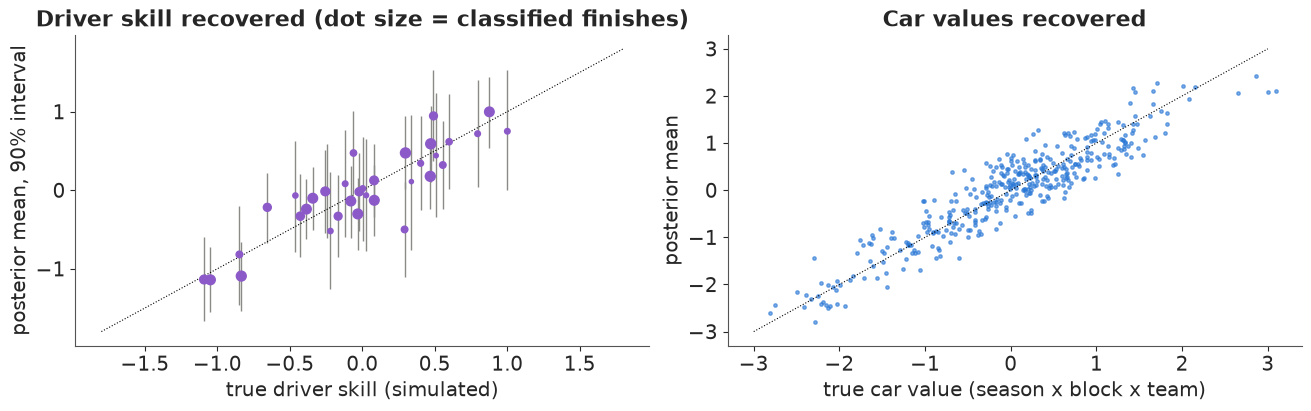

In [26]:
b_sim = draws(id_sim, "driver_skill")
c_sim = draws(id_sim, "car")
q_b = np.quantile(b_sim, [0.05, 0.95], axis=0)
q_c = np.quantile(c_sim, [0.05, 0.95], axis=0)
cov_b = np.mean((truth["driver_skill"] >= q_b[0]) & (truth["driver_skill"] <= q_b[1]))
cov_c = np.mean((car_true >= q_c[0]) & (car_true <= q_c[1]))
print(f"90% intervals cover the truth: driver skills {cov_b:.0%} of {len(drivers)}, "
      f"car values {cov_c:.0%} of {car_true.size}")
print(az.summary(id_sim, var_names=["sigma_driver", "sigma_form", "sigma_car", "sigma_dev"], round_to=3)
      [["mean", "sd", "eti89_lb", "eti89_ub", "r_hat"]])
print("true scales used: driver 0.6, form 0.25, car 1.0, development 0.4 "
      f"(realised sds: {truth['driver_skill'].std():.2f}, {truth['form'].std():.2f}, {truth['car0'].std():.2f}, "
      f"{truth['dev'][:, 1:].std():.2f})")
n_starts = np.bincount(arr_all["d"][valid_all], minlength=len(drivers))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].errorbar(truth["driver_skill"], b_sim.mean(axis=0),
                 yerr=[b_sim.mean(0) - q_b[0], q_b[1] - b_sim.mean(0)], fmt="none", ecolor=GREY, lw=1)
axes[0].scatter(truth["driver_skill"], b_sim.mean(axis=0), s=8 + n_starts / 3, color=PURPLE, zorder=3)
lim = [-1.8, 1.8]
axes[0].plot(lim, lim, color="k", lw=0.8, ls=":")
axes[0].set(xlabel="true driver skill (simulated)", ylabel="posterior mean, 90% interval",
            title="Driver skill recovered (dot size = classified finishes)")
axes[1].scatter(car_true.ravel(), c_sim.mean(axis=0).ravel(), s=6, color=BLUE, alpha=0.6)
axes[1].plot([-3, 3], [-3, 3], color="k", lw=0.8, ls=":")
axes[1].set(xlabel="true car value (season x block x team)", ylabel="posterior mean",
            title="Car values recovered");

The structure is recoverable: driver skills line up with the truth, with the widest intervals
for drivers with few races (small dots), car values are recovered for every season and block, and
90% intervals cover the truth 94% of the time for both. The hyperparameters come back close to the
realised spreads of the simulated values. This is the check that licenses reading the real fit.

## B3 · The real fit, and a check it fails

In [27]:
id_f1 = fit(f1_model(arr_all, valid_all), "F1 driver + car model")
print(worst(id_f1, ["driver_skill", "car_level", "dev_z", "form_z"]))
print(az.summary(id_f1, var_names=["sigma_driver", "sigma_form", "sigma_car", "sigma_dev"], round_to=3)
      [["mean", "sd", "eti89_lb", "eti89_ub", "r_hat", "ess_bulk"]])

F1 driver + car model: 7 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.006, min bulk ESS 865
               mean     sd  eti89_lb  eti89_ub  r_hat  ess_bulk
sigma_driver  0.666  0.126     0.482     0.884  1.003   983.499
sigma_form    0.283  0.065     0.181     0.388  1.004  1004.709
sigma_car     1.205  0.181     0.937     1.510  1.001  1109.999
sigma_dev     0.567  0.064     0.466     0.675  1.004   693.590


Clean sampling. Before reading any ranking off it, a posterior predictive check. We re-simulate
every session from 400 posterior draws with the Gumbel-max trick and look at two statistics:

* each driver-season's **average finishing position** - nearly a sufficient statistic again (the
  model has a form parameter per driver-season), so it should pass and tells us little;
* **teammate duels**: in each session where both cars of a team were classified, the
  replicated probability that the driver who actually finished ahead does so. Binned, predicted
  against observed, this is a calibration curve for the comparisons that identify driver skill.

In [28]:
def replicate(idata, arr, valid, n_draws=400, seed=12):
    """Replicated finishing positions (draws, sessions, slots) from the posterior, in-sample."""
    r = np.random.default_rng(seed)
    b_, f_ = draws(idata, "driver_skill"), draws(idata, "form_z") * draws(idata, "sigma_form")[:, None]
    c_ = draws(idata, "car")
    sel = r.choice(b_.shape[0], n_draws, replace=False)
    s_ = b_[sel][:, arr["d"]] + f_[sel][:, arr["ds"]] + c_[sel][:, arr["si"], arr["block"], arr["team_k"]]
    if "day_z" in idata.posterior:
        day = draws(idata, "day_z")[sel] * draws(idata, "sigma_day")[sel][:, None, None]
        s_ = s_ + np.take_along_axis(day, np.broadcast_to(arr["team_k"], (n_draws,) + arr["team_k"].shape), axis=2)
    u_ = np.where(valid, s_ + r.gumbel(size=s_.shape), -np.inf)
    return (-u_).argsort(axis=2).argsort(axis=2) + 1


pair_i, pair_1, pair_2 = [], [], []                  # sessions where both team cars were classified
for i in range(valid_all.shape[0]):
    t_k = arr_all["team_k"][i, :valid_all[i].sum()]
    for k in np.unique(t_k):
        slots = np.where(t_k == k)[0]
        if len(slots) == 2:                          # slots are in finishing order: slot 1 was ahead
            pair_i.append(i), pair_1.append(slots[0]), pair_2.append(slots[1])
pair_i, pair_1, pair_2 = map(np.array, (pair_i, pair_1, pair_2))
flip = np.random.default_rng(13).random(len(pair_i)) < 0.5   # random side, so outcomes are 0 and 1


def ppc_f1(pos_rep):
    """Driver-season mean-position check and binned teammate-duel calibration."""
    dsv = arr_all["ds"][valid_all]
    n_ds = np.bincount(dsv, minlength=len(ds_labels))
    obs_pos = np.tile(np.arange(1, valid_all.shape[1] + 1), (valid_all.shape[0], 1))[valid_all]
    m_obs = np.bincount(dsv, weights=obs_pos, minlength=len(ds_labels)) / np.maximum(n_ds, 1)
    m_rep = np.stack([np.bincount(dsv, weights=pr[valid_all], minlength=len(ds_labels)) for pr in pos_rep])
    m_rep = m_rep / np.maximum(n_ds, 1)
    ok_ds = n_ds >= 10
    lo_, hi_ = np.quantile(m_rep[:, ok_ds], [0.05, 0.95], axis=0)
    inside_ = np.mean((m_obs[ok_ds] >= lo_) & (m_obs[ok_ds] <= hi_))
    p_ahead = (pos_rep[:, pair_i, pair_1] < pos_rep[:, pair_i, pair_2]).mean(axis=0)
    p_side, y_side = np.where(flip, 1 - p_ahead, p_ahead), np.where(flip, 0.0, 1.0)
    cal = pd.DataFrame({"p": p_side, "y": y_side, "bin": np.digitize(p_side, np.linspace(0, 1, 11))}).groupby(
        "bin").agg(p=("p", "mean"), y=("y", "mean"), n=("y", "size"))
    brier = np.mean((p_side - y_side) ** 2)
    return inside_, ok_ds.sum(), cal, p_ahead, brier


inside_base, n_ok, cal_base, p_ahead_base, brier_base = ppc_f1(replicate(id_f1, arr_all, valid_all))
print(f"driver-seasons with 10+ finishes: {n_ok}; mean position inside the 90% predictive interval: "
      f"{inside_base:.0%}")
print(f"{len(pair_i):,} teammate duels; mean P(actual leader finishes ahead) = {p_ahead_base.mean():.2f}")
print(cal_base.round(2).T.to_string())

driver-seasons with 10+ finishes: 101; mean position inside the 90% predictive interval: 100%
1,111 teammate duels; mean P(actual leader finishes ahead) = 0.58
bin     1      2      3       4       5       6       7      8      9      10
p     0.08   0.14   0.26    0.36    0.45    0.54    0.65   0.74   0.85   0.92
y     0.03   0.00   0.18    0.19    0.50    0.57    0.66   0.82   0.94   0.92
n    37.00  18.00  84.00  103.00  323.00  307.00  107.00  76.00  18.00  38.00


The average-position check passes (as a near-sufficient statistic must). The teammate check does
not: in the upper bins the driver the model favours beat his teammate clearly more often than
predicted (and, symmetrically, less often in the lower bins). **The model is underconfident about
teammates.** The reason is structural. Plackett-Luce gives every car its own independent Gumbel
noise, so all race-day randomness - a good or bad strategy call, a set-up that suits the track, a
safety car at the right moment - is treated as independent between the two cars of a team. In
reality much of it is shared by both cars. The model must explain the big swings of a *team*
from race to race with independent noise, so it inflates the noise relative to the strengths, and
then teammate duels look more random than they are.

## B4 · The fix: a shared race-day effect per team

Add a random effect for each team in each session, $\sigma_\text{day}\, u_{c,r}$ with
$u_{c,r} \sim \mathcal N(0, 1)$, shared by both cars. It cancels in every teammate comparison and
absorbs the team's race-to-race swings (1,380 extra parameters, one per team per session).

In [29]:
id_f1d = fit(f1_model(arr_all, valid_all, race_day=True), "F1 model + race-day team effect")
print(worst(id_f1d, ["driver_skill", "car_level", "dev_z", "form_z", "day_z"]))
print(az.summary(id_f1d, var_names=["sigma_driver", "sigma_form", "sigma_car", "sigma_dev", "sigma_day"],
                 round_to=3)[["mean", "sd", "eti89_lb", "eti89_ub", "r_hat", "ess_bulk"]])
inside_day, _, cal_day, p_ahead_day, brier_day = ppc_f1(replicate(id_f1d, arr_all, valid_all))
print(f"mean position inside 90% interval: {inside_day:.0%}; teammate duels: mean P(actual leader ahead) "
      f"{p_ahead_base.mean():.2f} -> {p_ahead_day.mean():.2f}, Brier {brier_base:.3f} -> {brier_day:.3f}")

F1 model + race-day team effect: 7 s, 0 divergences, 400 warm-up steps per chain


max r_hat 1.012, min bulk ESS 495
               mean     sd  eti89_lb  eti89_ub  r_hat  ess_bulk
sigma_driver  0.983  0.175     0.735     1.271  1.004   856.566
sigma_form    0.260  0.081     0.130     0.391  1.007   617.570
sigma_car     1.560  0.227     1.229     1.936  1.003   950.735
sigma_dev     0.342  0.069     0.236     0.452  1.004   402.729
sigma_day     1.190  0.069     1.082     1.303  1.003   727.153
mean position inside 90% interval: 99%; teammate duels: mean P(actual leader ahead) 0.58 -> 0.59, Brier 0.205 -> 0.200


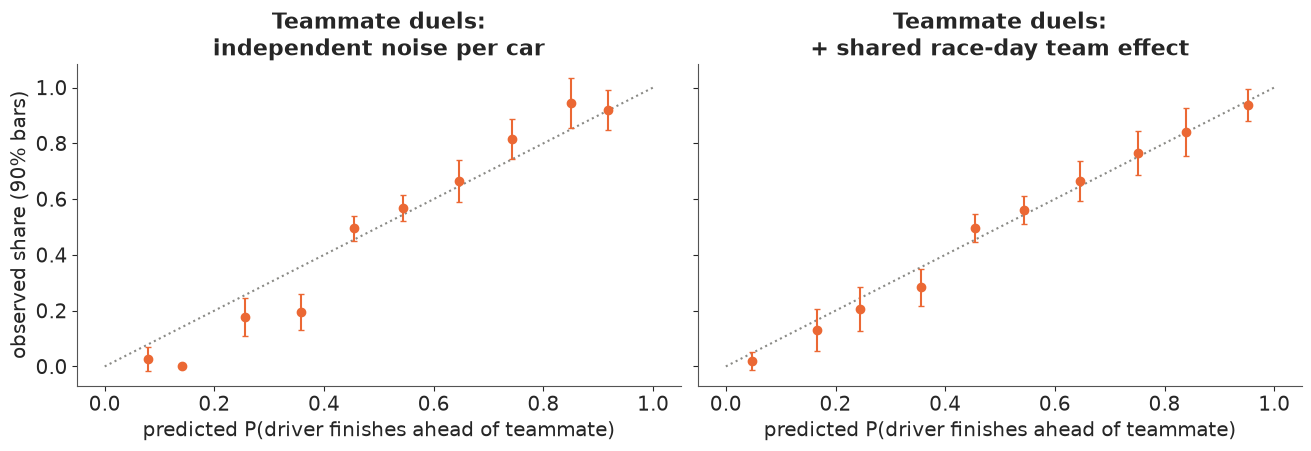

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for ax, cal, title in [(axes[0], cal_base, "independent noise per car"),
                       (axes[1], cal_day, "+ shared race-day team effect")]:
    ax.plot([0, 1], [0, 1], color=GREY, ls=":")
    ax.errorbar(cal.p, cal.y, yerr=1.64 * np.sqrt(cal.y * (1 - cal.y) / cal.n), fmt="o", color=ORANGE, capsize=2)
    ax.set(xlabel="predicted P(driver finishes ahead of teammate)", title=f"Teammate duels:\n{title}")
axes[0].set_ylabel("observed share (90% bars)");

The race-day scale is large - $\sigma_\text{day} \approx 1.2$, comparable to the spread of car
performance between teams ($\sigma_\text{car} \approx 1.6$) - and with it in place the teammate
duels are close to calibrated (right panel; Brier score of the duels 0.205 to 0.200). The other scales
grow too: once shared race-day noise is modelled separately, the independent Gumbel noise is a
smaller part of the story and the same results imply larger strength differences. (Pure scale
changes do not alter rankings, but they do change every probability computed from the model.)
From here on we use the race-day model.

P(Verstappen is the best driver 2021-2025, car removed) = 1.000; his skill minus the next best, 90% interval: [0.98 2.58]


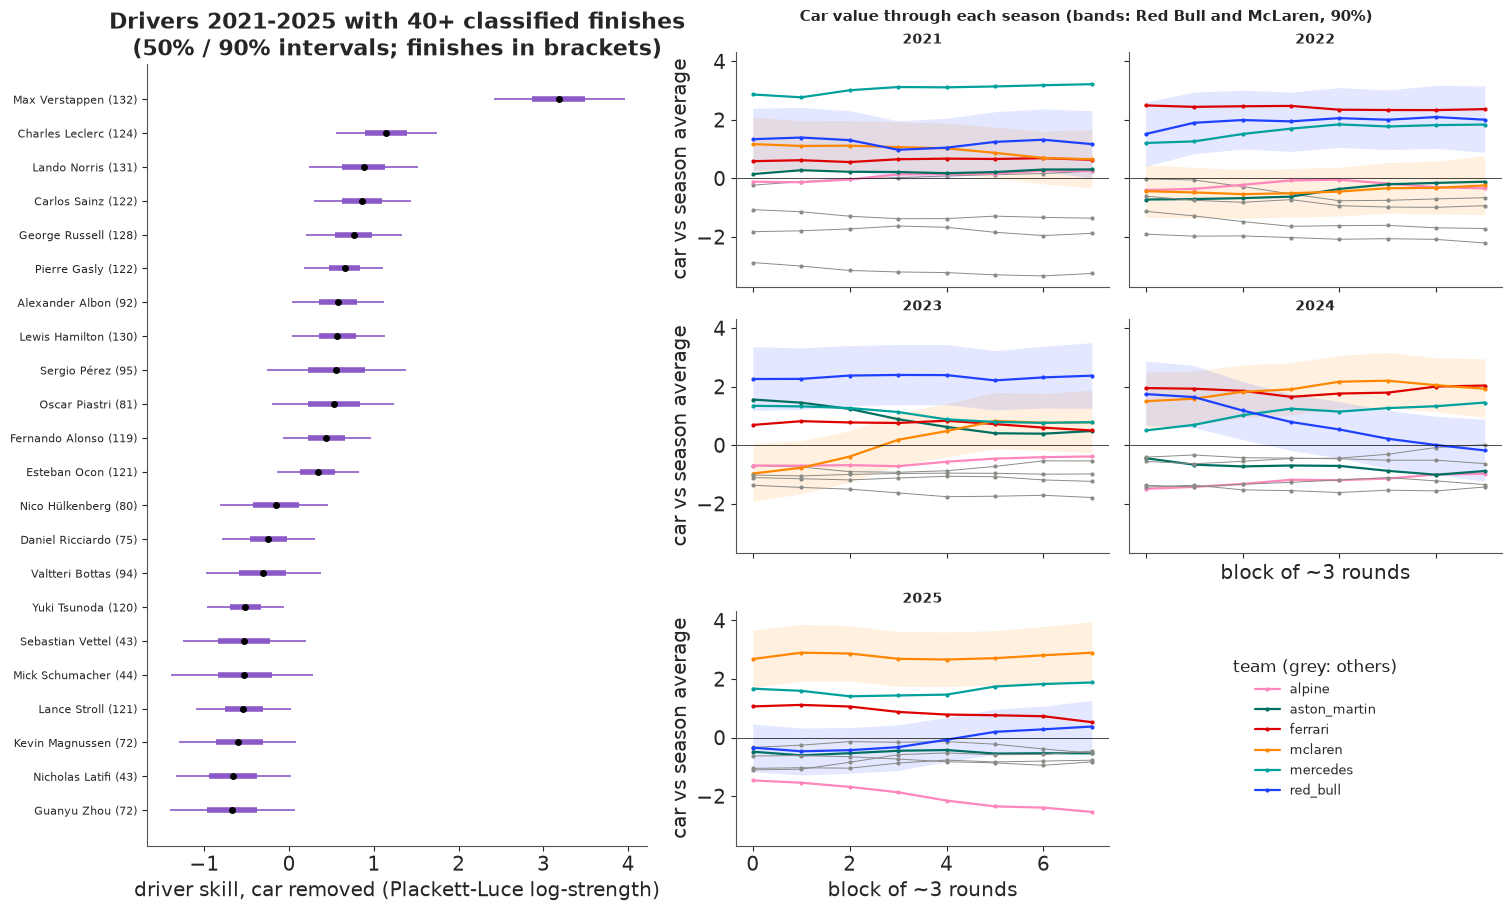

In [31]:
beta_d, form_d = draws(id_f1d, "driver_skill"), draws(id_f1d, "form_z") * draws(id_f1d, "sigma_form")[:, None]
car_d = draws(id_f1d, "car")
n_cls = np.bincount(arr_all["d"][valid_all], minlength=len(drivers))
names = f1.drop_duplicates("driver_id").set_index("driver_id").driver
fig = plt.figure(figsize=(15, 9))
sub = fig.subfigures(1, 2, width_ratios=[1, 1.3])
ax = sub[0].subplots()
keep = np.where(n_cls >= 40)[0]
kk = keep[np.argsort(beta_d[:, keep].mean(axis=0))]
q = np.quantile(beta_d[:, kk], [0.05, 0.25, 0.75, 0.95], axis=0)
yy = np.arange(len(kk))
ax.hlines(yy, q[0], q[3], color=PURPLE, lw=1.2)
ax.hlines(yy, q[1], q[2], color=PURPLE, lw=4)
ax.plot(beta_d[:, kk].mean(axis=0), yy, "o", color="k", ms=4)
ax.set_yticks(yy, [f"{names[drivers[k]]} ({n_cls[k]})" for k in kk], fontsize=8)
ax.set(xlabel="driver skill, car removed (Plackett-Luce log-strength)",
       title="Drivers 2021-2025 with 40+ classified finishes\n(50% / 90% intervals; finishes in brackets)")
axs = sub[1].subplots(3, 2, sharex=True, sharey=True).ravel()
TEAM_COL = {"red_bull": "#1e41ff", "mercedes": "#00a19c", "ferrari": "#dc0000", "mclaren": "#ff8700",
            "aston_martin": "#006f62", "alpine": "#ff87bc"}
for ax, si in zip(axs, range(len(SEASONS))):
    for k, team in enumerate(teams[SEASONS[si]]):
        col = TEAM_COL.get(team, GREY)
        ax.plot(np.arange(NB), car_d[:, si, :, k].mean(axis=0), "-o", ms=2, color=col,
                lw=1.6 if team in TEAM_COL else 0.7, label=team if team in TEAM_COL else None)
        if team in ("red_bull", "mclaren"):
            qq = np.quantile(car_d[:, si, :, k], [0.05, 0.95], axis=0)
            ax.fill_between(np.arange(NB), qq[0], qq[1], color=col, alpha=0.12, lw=0)
    ax.set_title(str(SEASONS[si]), fontsize=10)
    ax.axhline(0, color="k", lw=0.5)
axs[-1].axis("off")
handles, labels_ = axs[0].get_legend_handles_labels()
axs[-1].legend(handles, labels_, fontsize=9, loc="center", title="team (grey: others)")
for ax in axs[3:5]:
    ax.set_xlabel("block of ~3 rounds")
for ax in axs[0::2]:
    ax.set_ylabel("car vs season average")
sub[1].suptitle("Car value through each season (bands: Red Bull and McLaren, 90%)", fontsize=11)
p_best_drv = np.bincount(beta_d.argmax(axis=1), minlength=len(drivers)) / beta_d.shape[0]
k_ver = didx.get_loc("max_verstappen")
print(f"P(Verstappen is the best driver 2021-2025, car removed) = {p_best_drv[k_ver]:.3f}; "
      f"his skill minus the next best, 90% interval: "
      f"{np.quantile(beta_d[:, k_ver] - np.delete(beta_d, k_ver, axis=1).max(axis=1), [0.05, 0.95]).round(2)}");

**The drivers.** One driver stands apart: Verstappen's whole 90% interval lies to the right of
everyone else's, and his probability of being the best driver of the period is 1.00. Behind him
is a pack - Leclerc, Norris, Sainz, Russell, Gasly, Albon, Hamilton, Pérez, Piastri - whose
intervals overlap heavily; their order is not something five seasons of results can settle. At the
bottom are drivers who lost their seats.

**The cars** follow the known arc of the period: Mercedes ahead in 2021 with Red Bull second,
Ferrari ahead in 2022, Red Bull clearly ahead in 2023, McLaren rising through 2023 and 2024 while
Red Bull fell away in the second half of 2024, and McLaren leading 2025 with Red Bull climbing
from below the season average to slightly above it.

**A caveat that no likelihood can remove.** Verstappen's number is identified mainly by how far
he beat his Red Bull teammates (Pérez, Lawson, Tsunoda). "Verstappen is exceptional" and "the
Red Bull was built around Verstappen and was hard to drive for anyone else" predict the same
results. The model encodes the first by assumption (car and driver add up); the second would need
a driver x car interaction that these data can barely inform. That is also why the 2022 Red Bull
comes out *below* the Ferrari although Verstappen won 15 races that year: the model gives the
credit to the driver because his teammate did not win them.

## B5 · The decision: a 2025 title forecast, checked against the season

After round 15 of 2025 (the Dutch Grand Prix, end of August) the McLaren drivers led the
championship: Piastri 309 points, Norris 275, Verstappen 205, with nine Grands Prix and three
sprints to go. We refit both models (independent noise, and with the race-day effect) on
everything up to that weekend, simulate the rest of the season 4,000 times - car development
continues as the random walk into the unobserved blocks, each team gets a fresh race-day effect,
retirements happen at the 2025 rate so far, points follow the 2025 tables
(25-18-15-12-10-8-6-4-2-1 for a Grand Prix, 8-7-...-1 for a sprint) - and read off the title
probabilities and the distribution of each driver's final total. Then we look at what actually
happened.

In [32]:
CUT_ROUND = 15
f1_cut = f1[(f1.season < 2025) | (f1["round"] <= CUT_ROUND)]
arr_cut, valid_cut, _ = f1_arrays(f1_cut)
id_cut = {"independent noise": fit(f1_model(arr_cut, valid_cut), f"base model, data to 2025 round {CUT_ROUND}"),
          "race-day model": fit(f1_model(arr_cut, valid_cut, race_day=True),
                                f"race-day model, data to 2025 round {CUT_ROUND}")}
for k, v in id_cut.items():
    print(f"  {k}: {worst(v, ['driver_skill', 'car_level', 'dev_z', 'form_z'])}")

g25 = f1[f1.season == 2025]
codes = np.array(sorted(g25.driver_code.unique()))
cidx = pd.Index(codes)
pts_cut = g25[g25["round"] <= CUT_ROUND].groupby("driver_code").points.sum().reindex(codes).fillna(0).to_numpy()
pts_final = g25.groupby("driver_code").points.sum().reindex(codes).fillna(0).to_numpy()
dnf_rate = 1 - g25[g25["round"] <= CUT_ROUND].classified.mean()
GP_PTS, SPRINT_PTS = np.array([25, 18, 15, 12, 10, 8, 6, 4, 2, 1]), np.arange(8, 0, -1)
rest = g25[g25["round"] > CUT_ROUND]


def simulate_rest(idata, seed=15):
    """Final 2025 points: actual points to the cut + 4,000 simulated completions of the season."""
    r = np.random.default_rng(seed)
    b_, f_ = draws(idata, "driver_skill"), draws(idata, "form_z") * draws(idata, "sigma_form")[:, None]
    c_ = draws(idata, "car")
    sd_day = draws(idata, "sigma_day") if "sigma_day" in idata.posterior else np.zeros(b_.shape[0])
    n_s = b_.shape[0]
    tot = np.tile(pts_cut, (n_s, 1))
    for (_, session), x in rest.groupby(["round", "session"]):
        sk = b_[:, x.d.to_numpy()] + f_[:, x.ds.to_numpy()] + c_[:, 4, x.block.to_numpy(), x.team_k.to_numpy()]
        day = r.normal(size=(n_s, 10)) * sd_day[:, None]            # a new race day for each team
        u_ = sk + day[:, x.team_k.to_numpy()] + r.gumbel(size=sk.shape)
        u_[r.random(sk.shape) < dnf_rate] = -np.inf                  # retirements
        order = np.argsort(-u_, axis=1)
        for pos, pts in enumerate(GP_PTS if session == "race" else SPRINT_PTS):
            who = order[:, pos]
            fin = np.isfinite(u_[np.arange(n_s), who])
            np.add.at(tot, (np.arange(n_s)[fin], cidx.get_indexer(x.driver_code.to_numpy()[who[fin]])), pts)
    return tot


totals = {k: simulate_rest(v) for k, v in id_cut.items()}
print(f"retirement rate used: {dnf_rate:.1%}; remaining sessions: "
      f"{rest.groupby(['round', 'session']).ngroups} ({rest[rest.session == 'race']['round'].nunique()} Grands Prix)")
print(f"round {CUT_ROUND}: {g25[g25['round'] == CUT_ROUND].race.iloc[0]}, {g25[g25['round'] == CUT_ROUND].date.iloc[0]}")
for k, tot in totals.items():
    p_ch = np.bincount(tot.argmax(axis=1), minlength=len(codes)) / tot.shape[0]
    fc = pd.DataFrame({"points after R15": pts_cut, "P(champion)": p_ch,
                       "final 5%": np.quantile(tot, 0.05, axis=0), "median": np.median(tot, axis=0),
                       "95%": np.quantile(tot, 0.95, axis=0), "actual final": pts_final,
                       "actual percentile": (tot < pts_final).mean(axis=0)}, index=codes)
    print(f"\n{k}:")
    print(fc.sort_values("points after R15", ascending=False).head(5).round(3).to_string())

base model, data to 2025 round 15: 7 s, 0 divergences, 400 warm-up steps per chain


race-day model, data to 2025 round 15: 7 s, 0 divergences, 400 warm-up steps per chain


  independent noise: max r_hat 1.006, min bulk ESS 834


  race-day model: max r_hat 1.009, min bulk ESS 552


retirement rate used: 11.2%; remaining sessions: 12 (9 Grands Prix)
round 15: Dutch Grand Prix, 2025-08-31

independent noise:
     points after R15  P(champion)  final 5%  median     95%  actual final  actual percentile
PIA             309.0        0.898     344.0   416.0  487.00         410.0              0.443
NOR             275.0        0.046     295.0   352.0  420.00         423.0              0.959
VER             205.0        0.048     237.0   306.0  379.05         421.0              0.998
RUS             184.0        0.006     202.0   257.0  333.00         319.0              0.910
LEC             151.0        0.001     168.0   226.0  299.00         242.0              0.642

race-day model:
     points after R15  P(champion)  final 5%  median     95%  actual final  actual percentile
PIA             309.0        0.866    394.00   451.0  502.00         410.0              0.107
NOR             275.0        0.132    356.00   410.0  460.00         423.0              0.656
VER       

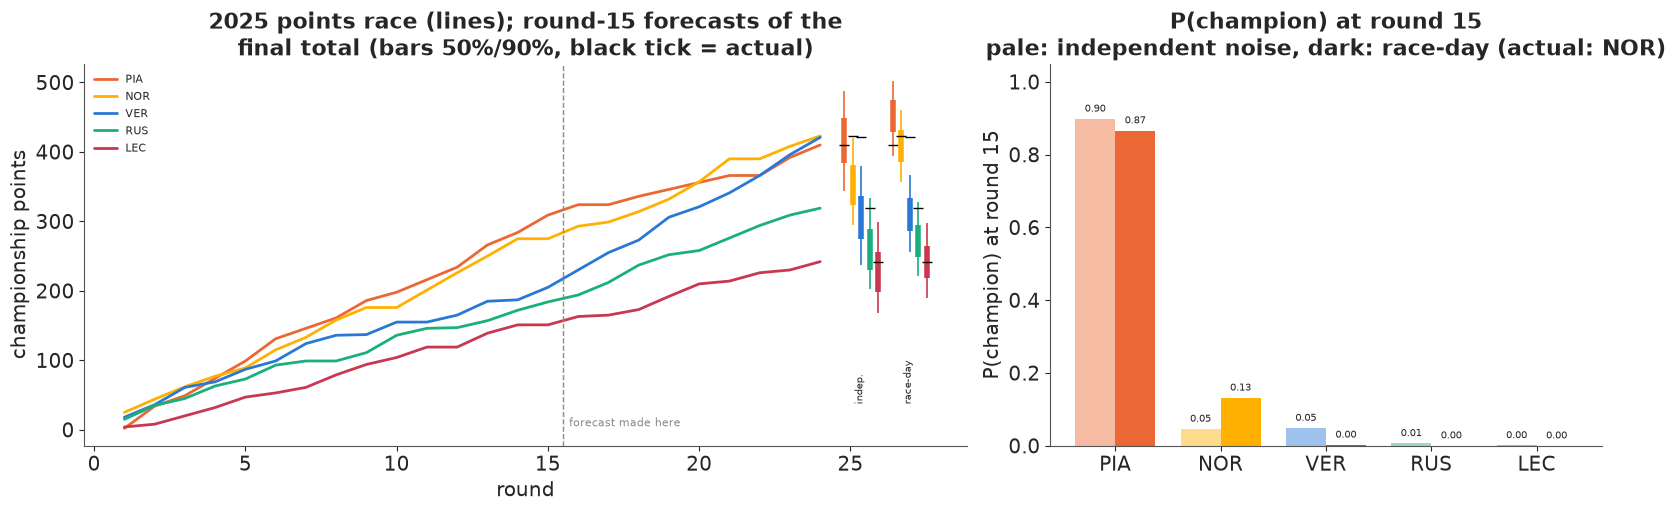

In [33]:
TOP = ["PIA", "NOR", "VER", "RUS", "LEC"]
cols = {"PIA": ORANGE, "NOR": "#ffb000", "VER": BLUE, "RUS": AQUA, "LEC": RED}
cum = g25.pivot_table(index="round", columns="driver_code", values="points", aggfunc="sum").fillna(0).cumsum()
fig, axes = plt.subplots(1, 2, figsize=(16, 5), width_ratios=[1.6, 1])
for c in TOP:
    axes[0].plot(cum.index, cum[c], color=cols[c], lw=2, label=c)
    k = cidx.get_loc(c)
    for j, (name, tot) in enumerate(totals.items()):
        xpos = 24.8 + 1.6 * j + 0.28 * TOP.index(c)
        qq = np.quantile(tot[:, k], [0.05, 0.25, 0.75, 0.95])
        axes[0].vlines(xpos, qq[0], qq[3], color=cols[c], lw=1.2)
        axes[0].vlines(xpos, qq[1], qq[2], color=cols[c], lw=4)
        axes[0].plot(xpos, pts_final[k], "_", color="k", ms=7)
for j, name in enumerate(totals):
    axes[0].text(25.3 + 1.6 * j, 40, ["indep.", "race-day"][j], fontsize=7, ha="center", rotation=90)
axes[0].axvline(CUT_ROUND + 0.5, color=GREY, ls="--", lw=1)
axes[0].text(CUT_ROUND + 0.7, 5, "forecast made here", fontsize=8, color=GREY)
axes[0].set(xlabel="round", ylabel="championship points",
            title="2025 points race (lines); round-15 forecasts of the\nfinal total (bars 50%/90%, black tick = actual)")
axes[0].legend(fontsize=8, loc="upper left")
wd = 0.38
for j, (name, tot) in enumerate(totals.items()):
    p_ch = np.bincount(tot.argmax(axis=1), minlength=len(codes)) / tot.shape[0]
    vals = [p_ch[cidx.get_loc(c)] for c in TOP]
    axes[1].bar(np.arange(len(TOP)) + (j - 0.5) * wd, vals, width=wd, color=[cols[c] for c in TOP],
                alpha=[0.45, 1.0][j], label=name)
    for i, v in enumerate(vals):
        axes[1].text(i + (j - 0.5) * wd, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)
axes[1].set_xticks(np.arange(len(TOP)), TOP)
champ = codes[pts_final.argmax()]
axes[1].set(ylim=(0, 1.05), ylabel="P(champion) at round 15",
            title=f"P(champion) at round 15\npale: independent noise, dark: race-day (actual: {champ})");

**What happened.** Both forecasts made Piastri a strong favourite (0.90 and 0.87). The title went
to Norris (0.05 and 0.13) by two points over Verstappen (0.05 and 0.002), with Piastri third. One
surprising outcome cannot refute a probability - favourites at 90% lose one time in ten. The
final totals say more than the winner does: **Verstappen's 421 points lie above the 99.8th
percentile of both forecasts** (their 95% points are about 380 and 367). He won six of the nine
remaining Grands Prix (lines, left). That is a failure of the models' assumptions, not bad luck.
Both assumed that the car order drifts slowly (a random walk with the step size learned from four
and a half seasons) and that a driver's form is constant within a season. The late-2025 Red Bull
improved faster than that, and the model had also learned from 2025 that Verstappen's car was
below average. The full-data fit in B4 absorbs part of this after the fact (its 2025 Red Bull line
climbs in the last blocks), but a forecast cannot anticipate a change faster than anything in its
training data. (Both McLarens were also disqualified at round 22 in Las Vegas, which the forecast
can only represent as an ordinary retirement.)

The race-day model, better calibrated on teammate duels, was *not* better here: it trusts the
McLaren's superiority more (Piastri's median final total 451 against 416, the actual 410 at its
11th percentile) and gives Verstappen even less. Fixing one check does not fix a model's
assumptions about change over time.

Lessons for anyone who forecasts from ratings: report *distributions* of final points, not only
title odds, so that a result can be checked for being inside or outside what the model allowed;
be most suspicious of long-horizon forecasts from models with slowly moving latent states; and
test the forecast machinery on past seasons before trusting it in the current one (Try it
yourself, 3).

## Summary

* **Bradley-Terry** turns sparse head-to-heads into skills by connecting everyone through common
  opponents. Skills are identified only up to a constant: a flat prior samples with zero
  divergences and r_hat 1.9; sum-to-zero (`pm.ZeroSumNormal`) fixes it and keeps uncertainties
  relative to the field, while anchoring one player inflates everyone else's.
* **Partial pooling** gives surface specialists with honest shrinkage ($\tau \approx 0.28$ logits
  against a skill spread of about 0.63).
* **Posterior predictive checks must look where the model is not tuned**: win totals are a
  sufficient statistic and always pass; the change in win share over time exposed the static
  model (16 of 56 players outside their 90% interval, 1 for the dynamic model).
* **Dynamic skills** (a Gaussian random walk per player) tell the story of 2021-2025 with
  uncertainty and a learned volatility. On the held-out year they tie a tuned Elo; online Elo,
  which sees the new results, is best.
* **Rankings are distributions**: P(best), rank intervals and simulated knockouts answer the
  questions a single ranked list cannot. Below the top three the ATP order is mostly noise, and
  a knockout spreads title chances well beyond P(best).
* **Plackett-Luce** scores whole finishing orders as a sequential softmax, checked by brute force,
  the Gumbel-max trick and a known-truth simulation. In Formula 1 it separates driver from car
  through teammates and team moves - up to the untestable assumption that they add. Its
  independent-noise assumption fails a teammate-duel check; a shared **race-day effect** per team
  fixes it.
* **Forecasts must be checked against what happened**: from round 15, both models made Piastri a
  90% favourite and put Verstappen's actual final total above their 99.8th percentile, because
  the 2025 season changed faster than a slow random walk allows.

## Try it yourself

1. **Best of five.** Grand Slam matches are best of five sets, which favours the stronger player.
   Add a factor $(1 + \kappa\,\text{bo5})$ multiplying the skill difference, with $\kappa \ge 0$,
   and see whether it improves the held-out log score and how it changes the knockout odds of a
   Grand Slam.
2. **Retirements as information.** Instead of dropping unclassified F1 starters, treat each as
   "behind all classified finishers" (the top-$k$ Plackett-Luce likelihood: stop the product at
   the number of classified cars, keep the retirees in the denominators). Which drivers move, and
   is a crash really uninformative about skill?
3. **Backtest the title forecast.** Repeat B5 for 2021-2024, making the forecast after two-thirds
   of each season, and record the actual champion's forecast probability and each top driver's
   final-points percentile. Are the percentiles roughly uniform, or is the model systematically
   overconfident? Does a larger development step (or a Student-t step) fix it?